<a href="https://colab.research.google.com/github/soonyz06/Broomburg/blob/main/HMM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Loading Data

In [ ]:
import re
from pathlib import Path
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, RobustScaler
from tqdm import tqdm
from datetime import date
import random
import math
from scipy.stats import norm
from scipy.integrate import quad
from itertools import combinations
import matplotlib.cm as cm
import matplotlib.gridspec as gridspec
from scipy.stats import norm
from scipy.integrate import quad


import warnings
import logging
logging.getLogger("hmmlearn").setLevel(logging.ERROR)

#!pip install hmmlearn
from hmmlearn.hmm import GaussianHMM

In [ ]:
lf = pl.scan_parquet("market_data.parquet")
display(lf.limit(5).collect())
print("\nSymbols: ", lf.select("symbol").unique().collect().to_series().to_list())
print("Columns:" , lf.collect_schema().names())
print("Rows:", lf.select(pl.len()).collect().item())

date,symbol,open,high,low,close,adjclose,volume
date,str,f64,f64,f64,f64,f64,f64
2012-08-09,"""IGF""",34.240002,34.459999,34.240002,34.380001,22.304886,17900.0
2007-10-23,"""IXP""",80.190002,80.489998,79.529999,80.449997,40.686016,64700.0
2021-11-24,"""TIP""",128.869995,129.240005,128.610001,129.199997,108.5401,2.7253e6
2024-10-30,"""USO""",70.669998,71.629997,70.360001,71.360001,71.360001,3.9344e6
2012-01-10,"""KXI""",33.355,33.355,33.174999,33.235001,23.502039,129600.0



Symbols:  ['UUP', 'VIXY', 'SOXX', 'SMH', 'ICLN', 'RING', 'USO', 'VT', 'IXJ', 'VEGI', 'LQD', 'REET', '^VIX', 'IXC', 'VXX', 'DBA', 'CARZ', 'IXG', 'IGF', 'TLT', 'TIP', 'IXP', 'EXI', 'CGW', 'JXI', 'HYG', 'ITA', 'RXI', 'IXN', 'XAR', 'IHAK', 'IEF', 'BOTZ', 'PICK', 'KXI', 'GLD', 'MXI', 'SPY']
Columns: ['date', 'symbol', 'open', 'high', 'low', 'close', 'adjclose', 'volume']
Rows: 190289


In [ ]:
#symbols_selected =["VOO", "BND", "VT", "GLD", "SLV", "DX-Y.NYB", "QQQ", "TLT", "IWM"]
symbols_selected = ["VT", "SPY", "GLD", "TLT", "UUP", "TIP", "^VIX"]
lf = (
    lf
    .filter(
        (pl.col("symbol").is_in(symbols_selected))
        # |(pl.col("symbol").str.contains(r"^[A-Z]{3}=X$"))
    )
)
display(lf.limit(5).collect())
print("\nSymbols: ", lf.select("symbol").unique().collect().to_series().to_list())
print("Columns:" , lf.collect_schema().names())
print("Rows:", lf.select(pl.len()).collect().item(), "\n")

date,symbol,open,high,low,close,adjclose,volume
date,str,f64,f64,f64,f64,f64,f64
2021-11-24,"""TIP""",128.869995,129.240005,128.610001,129.199997,108.5401,2.7253e6
2013-09-17,"""SPY""",170.460007,171.110001,170.460007,171.070007,137.180801,8.25233e7
2013-01-17,"""TIP""",121.199997,121.209999,121.0,121.139999,86.932022,596900.0
2023-06-09,"""VT""",95.480003,95.779999,95.209999,95.400002,89.47155,961700.0
1993-03-25,"""^VIX""",12.71,12.81,12.04,12.08,12.08,0.0



Symbols:  ['VT', 'GLD', '^VIX', 'TIP', 'TLT', 'UUP', 'SPY']
Columns: ['date', 'symbol', 'open', 'high', 'low', 'close', 'adjclose', 'volume']
Rows: 44120 



In [ ]:
def print_symbol_range(df, symbols_selected):
    print(
        lf.filter((pl.col("symbol").is_in(symbols_selected)))
        .group_by("symbol")
        .agg([
            pl.col("date").min().alias("min_date"),
            pl.col("date").max().alias("max_date"),
            pl.len().alias("rows")
        ])
        .collect()
    )

def mess_summary(df):
    print("")
    df_cols = df.columns
    n = df.height

    # only numeric cols for inf/zero checks
    num_cols = [c for c in df_cols if df[c].dtype in [pl.Float32, pl.Float64]]

    result = pl.DataFrame({
        "column": df_cols,

        # % null (works for all types)
        "pct_null": [(df[c].is_null().mean() * 100) for c in df_cols],

        # numeric-only metrics
        "pct_pos_inf": [
            (df[c].eq(float("inf")).mean() * 100) if c in num_cols else 0.0
            for c in df_cols
        ],
        "pct_neg_inf": [
            (df[c].eq(float("-inf")).mean() * 100) if c in num_cols else 0.0
            for c in df_cols
        ],
        "pct_zero": [
            (df[c].eq(0).mean() * 100) if c in num_cols else 0.0
            for c in df_cols
        ],
    })

    # keep only columns with ANY issue
    result = result.filter(
        (pl.col("pct_null") > 0) |
        (pl.col("pct_pos_inf") > 0) |
        (pl.col("pct_neg_inf") > 0) |
        (pl.col("pct_zero") > 0)
    )

    display(result)
    print("\n")

def missing_heatmap(df: pl.DataFrame):
    missing = df.select(
        [pl.col(c).is_null() for c in df.columns]
    ).to_numpy()

    plt.figure(figsize=(12, 6))

    plt.imshow(
        missing,
        aspect="auto"
    )

    plt.xticks(
        range(len(df.columns)),
        df.columns,
        rotation=90
    )

    plt.yticks(
        range(0, len(df), max(1, len(df)//10))
    )

    plt.xlabel("Columns")
    plt.ylabel("Rows")
    plt.title("Missing Values Heatmap")

    plt.show()

print_symbol_range(lf, symbols_selected)
mess_summary(lf.collect())

shape: (7, 4)
┌────────┬────────────┬────────────┬──────┐
│ symbol ┆ min_date   ┆ max_date   ┆ rows │
│ ---    ┆ ---        ┆ ---        ┆ ---  │
│ str    ┆ date       ┆ date       ┆ u32  │
╞════════╪════════════╪════════════╪══════╡
│ TIP    ┆ 2003-12-05 ┆ 2026-06-29 ┆ 5675 │
│ VT     ┆ 2008-06-26 ┆ 2026-06-29 ┆ 4529 │
│ ^VIX   ┆ 1990-01-02 ┆ 2026-06-30 ┆ 9191 │
│ UUP    ┆ 2007-03-01 ┆ 2026-06-29 ┆ 4863 │
│ GLD    ┆ 2004-11-18 ┆ 2026-06-29 ┆ 5435 │
│ SPY    ┆ 1993-01-29 ┆ 2026-06-29 ┆ 8410 │
│ TLT    ┆ 2002-07-30 ┆ 2026-06-29 ┆ 6017 │
└────────┴────────────┴────────────┴──────┘



column,pct_null,pct_pos_inf,pct_neg_inf,pct_zero
str,f64,f64,f64,f64
"""volume""",0.0,0.0,0.0,20.834089


In [ ]:
def clip_pct(df, col: str, p: float = 0.01):
    stats = (
        df.group_by("symbol")
        .agg([
            pl.col(col).quantile(p).alias("lower"),
            pl.col(col).quantile(1 - p).alias("upper"),
        ])
    )

    return (
        df.join(stats, on="symbol", how="left")
        .with_columns(
            pl.col(col).clip(pl.col("lower"), pl.col("upper"))
        )
        .drop(["lower", "upper"])
    )

def drop_pct(df, col: str, p: float = 0.01):
    stats = (
        df.group_by("symbol")
        .agg([
            pl.col(col).quantile(p).alias("lower"),
            pl.col(col).quantile(1 - p).alias("upper"),
        ])
    )

    return (
        df.join(stats, on="symbol", how="left")
        .filter(
            (pl.col(col) >= pl.col("lower")) &
            (pl.col(col) <= pl.col("upper"))
        )
        .drop(["lower", "upper"])
    )

def add_vol(df, window):
    span = window
    buffer = 0.7

    return (
        df

        # -------------------------
        # 1. Close-to-close EWMA vol
        # -------------------------
        .with_columns(
            (
                pl.col("log_ret")
                .ewm_var(span=span, min_samples=int(window * buffer))
                .over("symbol")
                .sqrt()
                * np.sqrt(252)
            ).alias(f"vol_ctc_{window}")
        )

        # -------------------------
        # 2. log components
        # -------------------------
        .with_columns([
            (pl.col("open") / pl.col("close").shift(1).over("symbol")).log().alias("r_o"),
            (pl.col("close") / pl.col("open")).log().alias("r_c"),
            (
                (pl.col("high") / pl.col("open")).log()
                * (pl.col("high") / pl.col("close")).log()
                +
                (pl.col("low") / pl.col("open")).log()
                * (pl.col("low") / pl.col("close")).log()
            ).alias("rs"),
        ])

        # -------------------------
        # 3. EWMA stats
        # -------------------------
        .with_columns([
            pl.col("r_o")
                .ewm_var(span=span, min_samples=int(window * buffer))
                .over("symbol")
                .alias("var_o"),

            pl.col("r_c")
                .ewm_var(span=span, min_samples=int(window * buffer))
                .over("symbol")
                .alias("var_c"),

            pl.col("rs")
                .ewm_mean(span=span, min_samples=int(window * buffer))
                .over("symbol")
                .alias("var_rs"),
        ])

        # -------------------------
        # 4. Yang–Zhang EWMA vol
        # -------------------------
        .with_columns(
            (
                (
                    pl.col("var_o")
                    + 0.34 * pl.col("var_c")   # you can keep alpha logic if you want
                    + (1 - 0.34) * pl.col("var_rs")
                ).sqrt()
                * np.sqrt(252)
            ).alias(f"vol_yz_{window}")
        )

        # -------------------------
        # 5. cleanup
        # -------------------------
        .select(pl.all().exclude(["r_o", "r_c", "rs", "var_o", "var_c", "var_rs"]))
    )

def add_moment(df, window):
    span = window
    buffer = 0.7

    return (
        df.with_columns([

            # EWMA mean
            pl.col("log_ret")
                .ewm_mean(span=span, min_samples=int(window * buffer))
                .over("symbol")
                .alias(f"log_ret_mu_{window}"),

            # EWMA variance
           # pl.col("log_ret")
            #    .ewm_var(span=span, min_samples=int(window * buffer))
             #   .over("symbol")
              #  .alias(f"log_ret_var_{window}"),
        ])
    )

def add_momentum(df, window):
    return df.with_columns([
        pl.col("log_ret")
        .rolling_sum(window)
        .over("symbol")
        .alias(f"mom_{window}")
    ])

def add_lags(df, cols, lag=1):
    return df.with_columns([
        pl.col(col)
        .shift(lag)
        .over("symbol")
        .alias(f"{col}_t-{lag}")
        for col in cols
    ])

def add_vol_adj_ret(df, window, vol_type="ctc"):
    vol_col = f"vol_{vol_type}_{window}"
    return df.with_columns(
        (
            pl.col("log_ret")
            / (pl.col(vol_col).shift(1).over("symbol") / np.sqrt(252))
        ).alias(f"log_ret_voladj_{window}_{vol_type}")
    )

data = (
    lf
    .drop("volume")
    .drop_nulls()
    .sort(["symbol", "date"])
    .with_columns([
        pl.col("close").log().diff().over("symbol").alias("log_ret")
    ])
    .pipe(add_vol, window=20)
    .pipe(add_moment, window=20)
    .pipe(add_momentum, window=20)
    .pipe(add_vol_adj_ret, window=20, vol_type="yz")
    .drop_nulls() #from created features
).select(pl.all().exclude(["open", "high", "low", "close"])).collect()
display(data.head())
mess_summary(data)

date,symbol,adjclose,log_ret,vol_ctc_20,vol_yz_20,log_ret_mu_20,mom_20,log_ret_voladj_20_yz
date,str,f64,f64,f64,f64,f64,f64,f64
2004-12-17,"""GLD""",44.189999,0.011608,0.167257,0.184248,-0.000365,-0.00429,0.976964
2004-12-20,"""GLD""",44.34,0.003389,0.158938,0.176025,0.000043,-0.009874,0.291967
2004-12-21,"""GLD""",44.220001,-0.00271,0.150716,0.168465,-0.000252,-0.016374,-0.244397
2004-12-22,"""GLD""",44.02,-0.004533,0.144043,0.161087,-0.000705,-0.016447,-0.427157
2004-12-23,"""GLD""",44.27,0.005663,0.139899,0.155014,-0.000038,-0.017466,0.558083


column,pct_null,pct_pos_inf,pct_neg_inf,pct_zero
str,f64,f64,f64,f64
"""log_ret""",0.0,0.0,0.0,1.143702
"""mom_20""",0.0,0.0,0.0,0.238745
"""log_ret_voladj_20_yz""",0.0,0.0,0.0,1.143702


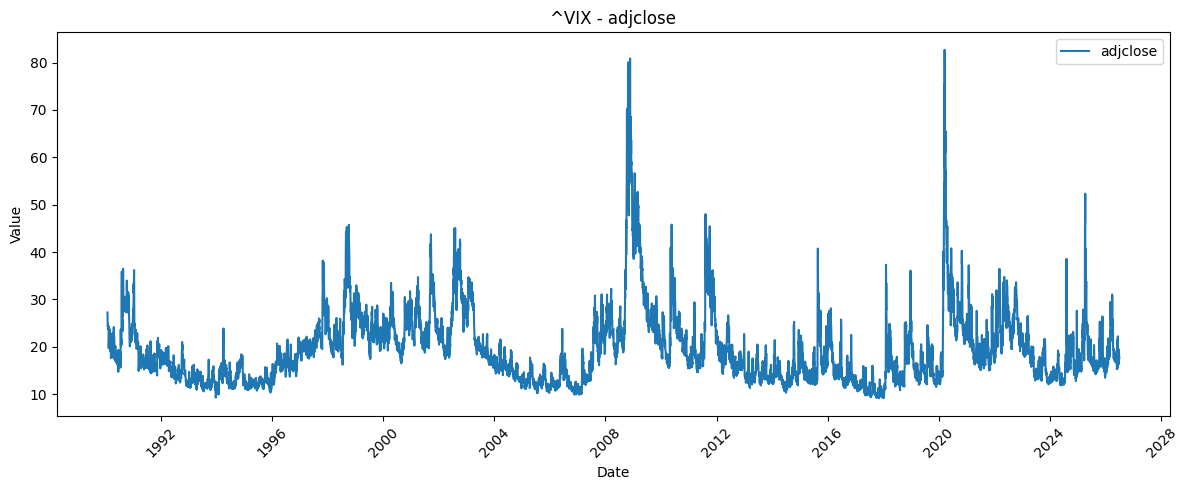

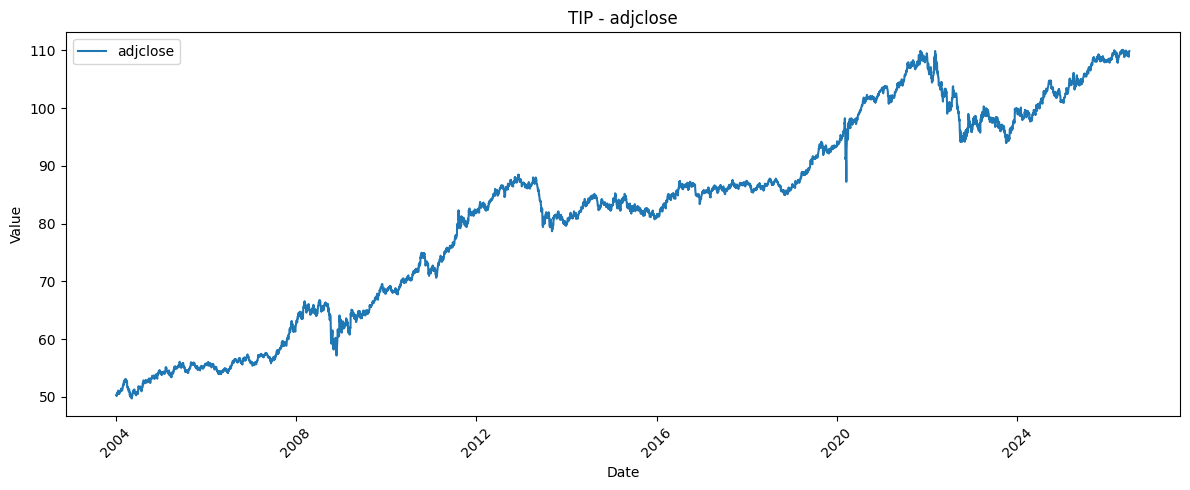

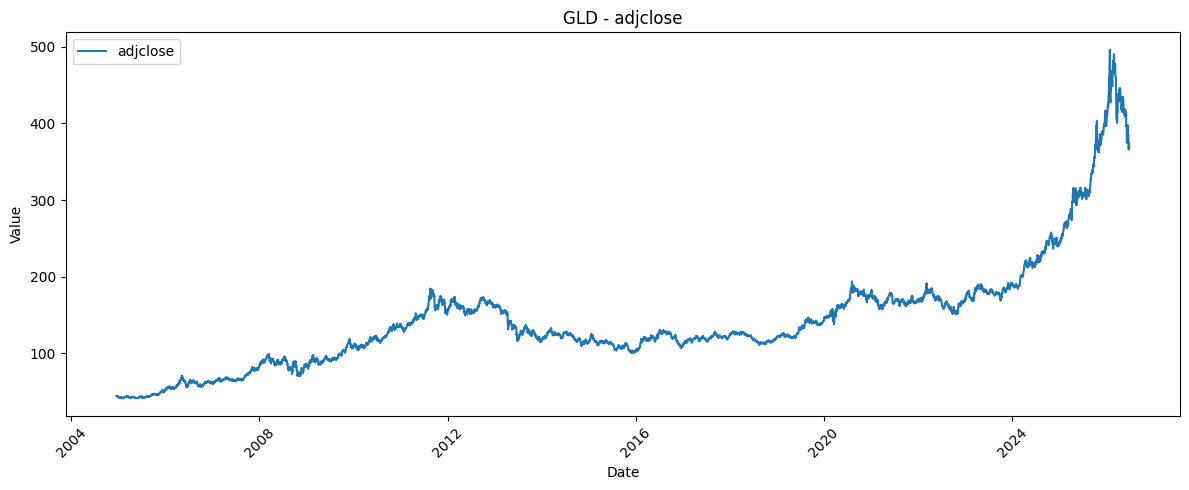

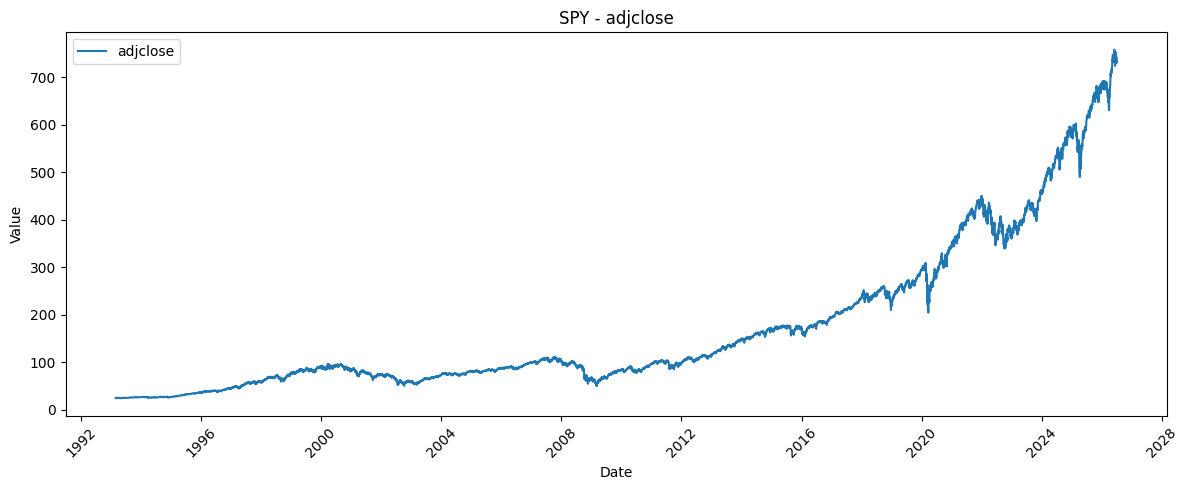

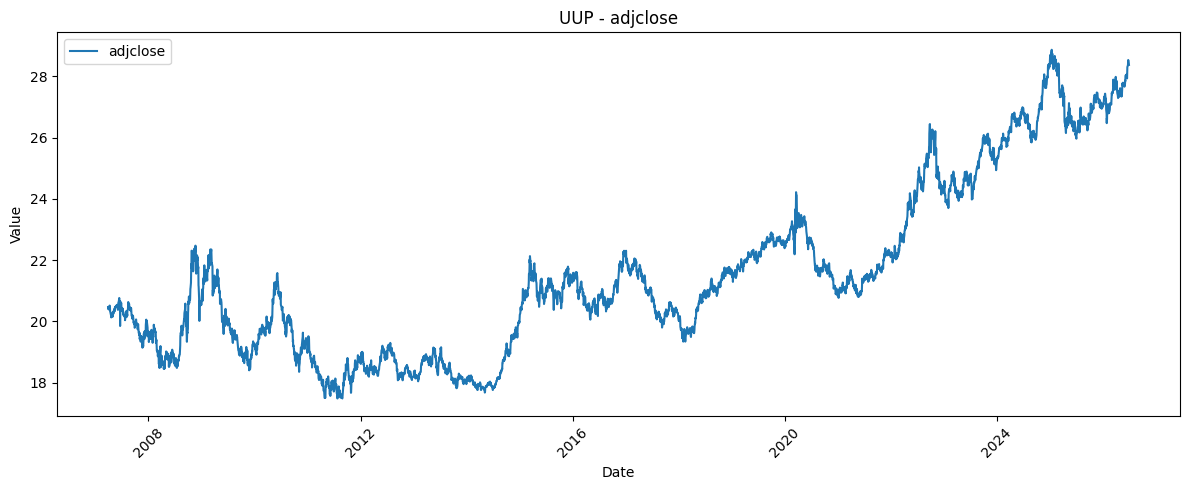

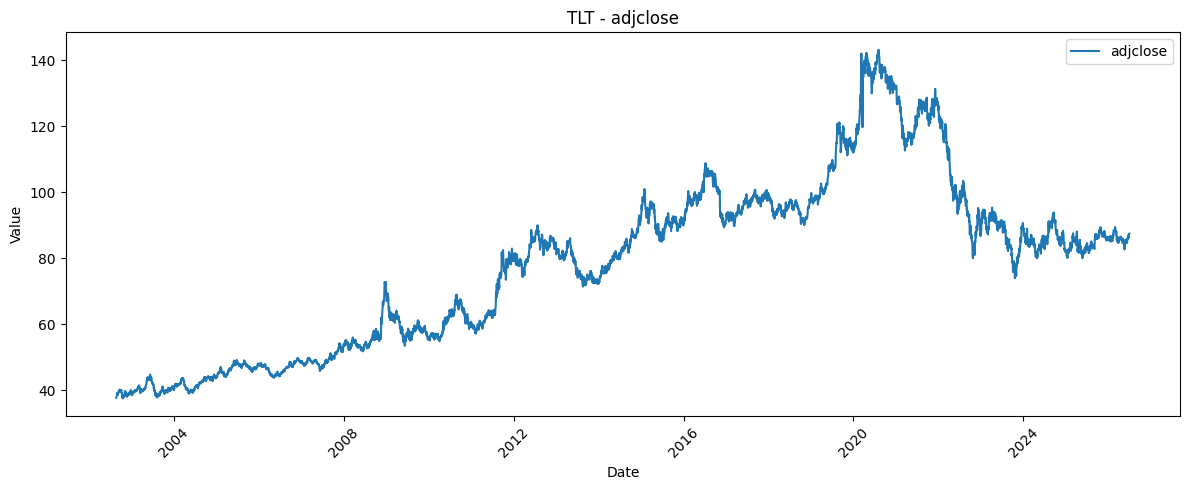

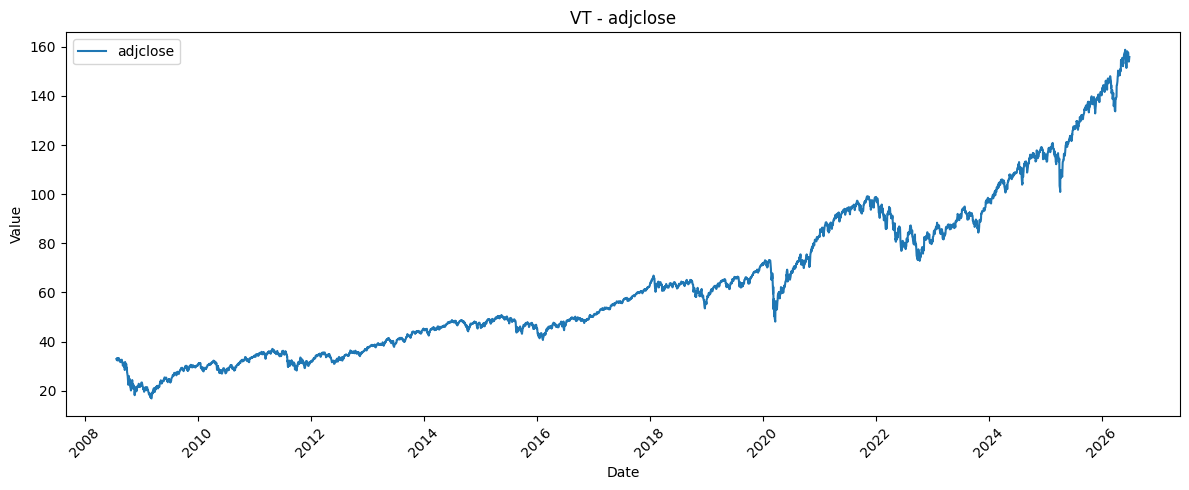

In [ ]:
def plot_symbol(df, symbol, col1="close", col2=None, date_col="date", symbol_col="symbol"):
    dff = (
        df
        .filter(pl.col(symbol_col) == symbol)
        .select([date_col, col1] + ([col2] if col2 else []))
        .sort(date_col)
    )

    pdf = dff.to_pandas()

    plt.figure(figsize=(12, 5))

    # always 1 line per column
    plt.plot(pdf[date_col], pdf[col1], label=col1)

    if col2 is not None:
        plt.plot(pdf[date_col], pdf[col2], label=col2)

    plt.title(f"{symbol} - {col1}" + (f" vs {col2}" if col2 else ""))
    plt.xlabel("Date")
    plt.ylabel("Value")
    plt.xticks(rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.show()

for i in data["symbol"].unique().to_list():#random.sample(data["symbol"].unique().to_list(), k=1):
  plot_symbol(data, i, "adjclose")
  #plot_symbol(data, i, "log_ret", "log_ret_mu_20")
  #plot_symbol(data, i, "vol_ctc_20", "vol_yz_20")
  print("\n")

date,GLD_log_ret,SPY_log_ret,TIP_log_ret,TLT_log_ret,UUP_log_ret,VT_log_ret,^VIX_log_ret
date,f64,f64,f64,f64,f64,f64,f64
2008-07-25,0.003934,-0.000239,-0.006901,-0.010045,0.001328,0.004365,-0.02287
2008-07-28,0.000436,-0.014772,0.008502,0.010045,-0.002215,-0.016101,0.056018
2008-07-29,-0.012506,0.021128,-0.006796,-0.004072,0.00839,0.00965,-0.095186
2008-07-30,-0.011882,0.017661,0.004158,0.000992,-0.00088,0.016564,-0.037932
2008-07-31,0.006236,-0.013315,0.004141,0.009866,0.0,-0.010113,0.078409


date,GLD_log_ret_SPY_log_ret_corr_60,GLD_log_ret_TIP_log_ret_corr_60,GLD_log_ret_TLT_log_ret_corr_60,GLD_log_ret_UUP_log_ret_corr_60,GLD_log_ret_VT_log_ret_corr_60,GLD_log_ret_^VIX_log_ret_corr_60,SPY_log_ret_TIP_log_ret_corr_60,SPY_log_ret_TLT_log_ret_corr_60,SPY_log_ret_UUP_log_ret_corr_60,SPY_log_ret_VT_log_ret_corr_60,SPY_log_ret_^VIX_log_ret_corr_60,TIP_log_ret_TLT_log_ret_corr_60,TIP_log_ret_UUP_log_ret_corr_60,TIP_log_ret_VT_log_ret_corr_60,TIP_log_ret_^VIX_log_ret_corr_60,TLT_log_ret_UUP_log_ret_corr_60,TLT_log_ret_VT_log_ret_corr_60,TLT_log_ret_^VIX_log_ret_corr_60,UUP_log_ret_VT_log_ret_corr_60,UUP_log_ret_^VIX_log_ret_corr_60,VT_log_ret_^VIX_log_ret_corr_60
date,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
2008-10-17,-0.355272,0.320234,0.174816,-0.650035,-0.245583,0.37837,-0.233334,-0.518202,0.095522,0.926341,-0.891497,0.498473,-0.214191,-0.168697,0.245758,0.028354,-0.551113,0.612977,-0.005383,-0.196859,-0.830653
2008-10-20,-0.322583,0.335607,0.187327,-0.636491,-0.212905,0.312209,-0.160385,-0.482125,0.114055,0.930765,-0.889938,0.498077,-0.186298,-0.089803,0.117863,0.035025,-0.505575,0.523955,0.019152,-0.216565,-0.840391
2008-10-21,-0.304149,0.327207,0.177137,-0.645657,-0.177278,0.310876,-0.159984,-0.483458,0.087413,0.926309,-0.88391,0.490602,-0.162975,-0.092965,0.109544,0.054151,-0.504467,0.520105,-0.028854,-0.211666,-0.818479
2008-10-22,-0.239181,0.275548,0.107047,-0.653781,-0.104256,0.201781,-0.175669,-0.503077,0.04988,0.928798,-0.882181,0.503043,-0.132616,-0.119675,0.138187,0.090797,-0.530509,0.551282,-0.067237,-0.142675,-0.831474
2008-10-23,-0.239496,0.284074,0.102876,-0.645025,-0.102406,0.202143,-0.191809,-0.497568,0.046159,0.927362,-0.881957,0.488232,-0.109208,-0.129213,0.152343,0.080744,-0.529272,0.545701,-0.065046,-0.138357,-0.829961


date,GLD_mom_20,SPY_mom_20,TIP_mom_20,TLT_mom_20,UUP_mom_20,VT_mom_20,^VIX_mom_20,GLD_vol_yz_20,SPY_vol_yz_20,TIP_vol_yz_20,TLT_vol_yz_20,UUP_vol_yz_20,VT_vol_yz_20,^VIX_vol_yz_20
date,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
2008-07-25,0.011849,-0.021679,-0.017212,-0.012239,0.00399,-0.028021,-0.043559,0.213609,0.210697,0.077627,0.108725,0.106417,0.260365,0.931373
2008-07-28,0.002838,-0.030978,-0.013454,-0.013852,0.00489,-0.042507,0.033148,0.207617,0.207991,0.08331,0.115982,0.102584,0.278337,0.913819
2008-07-29,-0.008902,-0.013372,-0.021178,-0.018141,0.011055,-0.033665,-0.083563,0.203417,0.209959,0.082719,0.11434,0.100801,0.268676,0.910162
2008-07-30,-0.034475,0.001168,-0.010508,-0.011175,0.011065,-0.00818,-0.10889,0.223039,0.208982,0.084623,0.120341,0.10311,0.258938,0.879608
2008-07-31,-0.033728,0.005138,-0.0126,-0.006524,0.015972,-0.00352,-0.122133,0.232397,0.2106,0.083916,0.1288,0.110163,0.246704,0.899626


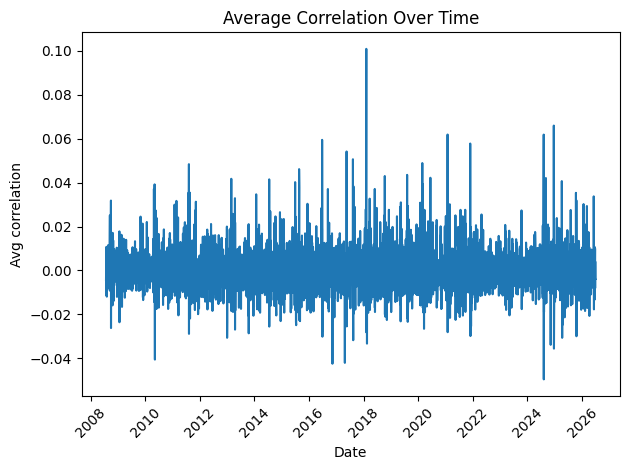

In [ ]:
def long_to_wide(df: pl.DataFrame, col: str):
    wide = (
        df.pivot(
            values=col,
            index="date",
            on="symbol",
            aggregate_function="mean"
        )
        .rename({
            c: f"{c}_{col}"
            for c in df["symbol"].unique().to_list()
        })
    )
    return wide

def add_rolling_correlations(df, window=60, suffix="_log_ret"):
    cols = [c for c in df.columns if c.endswith(suffix)]
    corr_features = [
        pl.rolling_corr(
            pl.col(a),
            pl.col(b),
            window_size=window
        ).alias(f"{a}_{b}_corr_{window}")
        for a, b in combinations(cols, 2)
    ]
    return df.with_columns(corr_features).drop(cols)

def plot_avg_corr(df: pl.DataFrame):
    value_cols = [c for c in df.columns if c != "date"]

    df_avg = (
        df.with_columns(
            pl.mean_horizontal([pl.col(c) for c in value_cols]).alias("avg_corr")
        )
        .sort("date")
    )

    dates = df_avg["date"].to_list()
    avg = df_avg["avg_corr"].to_list()

    plt.figure()
    plt.plot(dates, avg)
    plt.title("Average Correlation Over Time")
    plt.xlabel("Date")
    plt.ylabel("Avg correlation")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    return df_avg.drop(value_cols)


log_ret = long_to_wide(data, "log_ret").drop_nulls().sort("date")
display(log_ret.head())

corr = add_rolling_correlations(log_ret, window=60).drop_nulls().sort("date")
display(corr.head())

ret = long_to_wide(data, "mom_20")
vol = long_to_wide(data, "vol_yz_20")
wide = ret.join(
    vol,
    on="date",
    how="inner",
).drop_nulls().sort("date")
display(wide.head())

avg_corr = plot_avg_corr(log_ret)

## Train

100%|██████████| 178/178 [00:26<00:00,  6.64it/s]


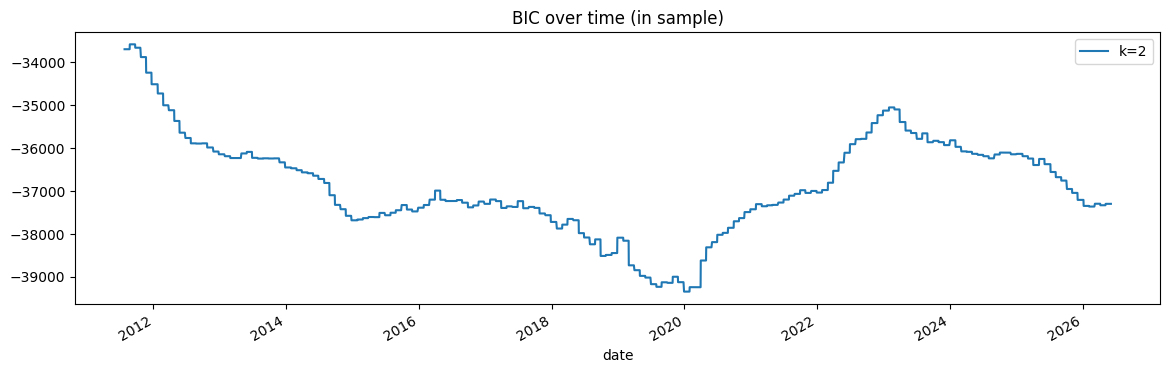

In [ ]:
def _fit_hmm(
    X_train: np.ndarray,
    k: int,
    covariance_type: str = "diag",
    n_iter: int = 200,
    random_state: int = 42,
    n_restarts: int = 5,
    min_state_occupancy: float = 5.0,
):
    """
    Fit a GaussianHMM with multiple random restarts, keep the best by
    training log-likelihood, reject degenerate fits, and canonicalize
    state ordering by ascending mean of the first feature.

    Returns (model, bic, train_loglik) or None if no restart produced a
    usable fit.
    """
    best_model, best_score = None, -np.inf

    for seed in range(n_restarts):
        m = GaussianHMM(
            n_components=k,
            covariance_type=covariance_type,
            n_iter=n_iter,
            random_state=random_state + seed,
            transmat_prior=np.ones((k, k)) + 1.0,
            startprob_prior=np.ones(k) + 1.0,
        )
        try:
            m.fit(X_train)

            if np.any(m.transmat_.sum(axis=1) == 0):
                continue  # absorbing/unreachable state

            # reject fits where any state has negligible effective occupancy
            # (these produce degenerate/blown-up variance estimates)
            posteriors = m.predict_proba(X_train)
            occupancy = posteriors.sum(axis=0)
            if (occupancy < min_state_occupancy).any():
                continue

            score = m.score(X_train)
            if score > best_score:
                best_score, best_model = score, m
        except Exception:
            continue

    if best_model is None:
        return None

    n_params = sum(best_model._get_n_fit_scalars_per_param().values())
    bic = -2 * best_score + n_params * np.log(len(X_train))

    # canonicalize state order by ascending mean of first feature.
    # IMPORTANT: reorder `_covars_` (compact internal storage), NOT the
    # public `covars_` property. For covariance_type="diag", the getter
    # expands _covars_ from (k, n_dim) into full (k, n_dim, n_dim)
    # matrices, but the setter expects the compact (k, n_dim) shape back
    # -- so `model.covars_ = model.covars_[order]` raises a shape
    # mismatch. Reordering `_covars_` directly keeps the shape compact
    # on both sides (verified safe: matches expected reorder, and the
    # public getter still works correctly afterward).
    order = np.argsort(best_model.means_[:, 0])
    best_model.means_ = best_model.means_[order]
    best_model._covars_ = best_model._covars_[order]
    best_model.startprob_ = best_model.startprob_[order]
    best_model.transmat_ = best_model.transmat_[np.ix_(order, order)]

    return best_model, bic, best_score


def _forward_filter(log_emiss: np.ndarray, transmat: np.ndarray, init_filtered: np.ndarray):
    """
    One-step-ahead forward algorithm.

    Returns
    -------
    filtered  : (T, k) P(state_t | obs_0..obs_t)      -- belief AFTER seeing obs_t
    predicted : (T, k) P(state_t | obs_0..obs_{t-1})  -- belief BEFORE seeing obs_t (the forecast)
    """
    T, k = log_emiss.shape
    log_alpha = np.zeros((T, k))
    predicted = np.zeros((T, k))

    pred0 = init_filtered @ transmat
    predicted[0] = pred0
    log_alpha[0] = np.log(pred0 + 1e-300) + log_emiss[0]
    mx = log_alpha[0].max()
    log_alpha[0] -= mx + np.log(np.sum(np.exp(log_alpha[0] - mx)))

    for t in range(1, T):
        prev_filtered = np.exp(log_alpha[t - 1])
        pred = prev_filtered @ transmat
        predicted[t] = pred
        log_alpha[t] = np.log(pred + 1e-300) + log_emiss[t]
        mx = log_alpha[t].max()
        log_alpha[t] -= mx + np.log(np.sum(np.exp(log_alpha[t] - mx)))

    filtered = np.exp(log_alpha)
    return filtered, predicted


def _posterior_weighted_moments(probs: np.ndarray, means: np.ndarray, vars_: np.ndarray):
    """Probability-weighted mean/std given any (T, k) probability array
    (filtered, predicted, or smoothed)."""
    pw_mean = probs @ means
    pw_var = probs @ (vars_ + means ** 2) - pw_mean ** 2
    pw_std = np.sqrt(np.maximum(pw_var, 1e-12))
    return pw_mean, pw_std


def _state_params_rows(model, k: int, assets: list[str], date) -> list[dict]:
    """One row per state: emission mean/std at this refit date."""
    means = model.means_
    stds = np.sqrt(np.stack([model.covars_[i].diagonal() for i in range(k)], axis=0))

    rows = []
    for s in range(k):
        row = {"date": date, "k": k, "state": s}
        for i, asset in enumerate(assets):
            row[f"mean_{asset}"] = means[s, i]
            row[f"std_{asset}"] = stds[s, i]
        rows.append(row)
    return rows


# --------------------------------------------------------------------------
# orchestration
# --------------------------------------------------------------------------

def run_rolling_hmm_wide(
    returns: pd.DataFrame,
    window: int = 252,
    step: int = 21,
    n_states=2,
    covariance_type: str = "diag",
    n_iter: int = 200,
    random_state: int = 42,
    n_restarts: int = 5,
    min_state_occupancy: float = 5.0,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Walk-forward fit a Gaussian HMM on a rolling window; compute one-step-
    ahead predicted (forward-filtered) state probabilities and z-scores for
    the out-of-sample block at each refit.

    Returns
    -------
    results : pd.DataFrame
        Index = date of first OOS row per window.
        Columns: k, bic, log_likelihood, z_<asset>, pw_mean_<asset>,
                 pw_std_<asset>, realized_<asset>
    state_params : pd.DataFrame
        Long format, one row per (refit_date, k, state):
            date, k, state, mean_<asset>, std_<asset>
        NOTE: contains rows for every k in n_states if a list was passed --
        filter by `k` before plotting/analysis.
    """
    dates = returns.index
    assets = returns.columns.tolist()
    X = returns.to_numpy(dtype=float)
    T, N = X.shape

    records = []
    state_param_records = []
    k_list = [n_states] if isinstance(n_states, int) else list(n_states)

    for start in tqdm(range(0, T - window - step + 1, step)):
        end = start + window
        oos_end = min(end + step, T)

        X_train = X[start:end]
        X_oos = X[end:oos_end]
        if len(X_oos) == 0:
            continue

        for k in k_list:
            result = _fit_hmm(
                X_train, k=k, covariance_type=covariance_type,
                n_iter=n_iter, random_state=random_state, n_restarts=n_restarts,
                min_state_occupancy=min_state_occupancy,
            )
            if result is None:
                continue
            model, bic, _ = result

            try:
                ll = model.score(X_oos)
            except Exception:
                ll = np.nan

            try:
                log_emiss_train = model._compute_log_likelihood(X_train)
                filtered_train, _ = _forward_filter(log_emiss_train, model.transmat_, model.startprob_)
                last_filtered_train = filtered_train[-1]

                log_emiss_oos = model._compute_log_likelihood(X_oos)
                _, predicted_oos = _forward_filter(log_emiss_oos, model.transmat_, last_filtered_train)
            except Exception:
                continue

            means = model.means_
            vars_ = np.stack([model.covars_[i].diagonal() for i in range(k)], axis=0)
            pw_mean_daily, pw_std_daily = _posterior_weighted_moments(predicted_oos, means, vars_)
            z_daily = (X_oos - pw_mean_daily) / pw_std_daily

            state_param_records.extend(_state_params_rows(model, k, assets, dates[end]))

            for t in range(len(X_oos)):
                row = {"_idx": dates[end + t], "k": k, "bic": bic, "log_likelihood": ll}
                for i, asset in enumerate(assets):
                    row[f"z_{asset}"] = z_daily[t, i]
                    row[f"pw_mean_{asset}"] = pw_mean_daily[t, i]
                    row[f"pw_std_{asset}"] = pw_std_daily[t, i]
                    row[f"realized_{asset}"] = X_oos[t, i]
                records.append(row)

    results = pd.DataFrame(records).set_index("_idx")
    results.index.name = "date"
    state_params = pd.DataFrame(state_param_records)

    return results, state_params


def run_live_hmm_wide(
    returns_recent: pd.DataFrame,
    k: int = 2,
    covariance_type: str = "diag",
    n_iter: int = 200,
    random_state: int = 42,
    n_restarts: int = 5,
    min_state_occupancy: float = 5.0,
) -> tuple:
    """Single fit on the most recent window; one-step-ahead forecast made
    BEFORE seeing the latest row (consistent with run_rolling_hmm_wide's
    OOS convention: predicted, not smoothed)."""
    dates = returns_recent.index
    assets = returns_recent.columns.tolist()
    X = returns_recent.to_numpy(dtype=float)

    result = _fit_hmm(
        X, k=k, covariance_type=covariance_type,
        n_iter=n_iter, random_state=random_state, n_restarts=n_restarts,
        min_state_occupancy=min_state_occupancy,
    )
    if result is None:
        raise RuntimeError(f"HMM failed to fit at k={k}.")
    model, bic, best_score = result

    ll = model.score(X)

    log_emiss = model._compute_log_likelihood(X)
    filtered, predicted = _forward_filter(log_emiss, model.transmat_, model.startprob_)

    means = model.means_
    vars_ = np.stack([model.covars_[i].diagonal() for i in range(k)], axis=0)
    pw_mean, pw_std = _posterior_weighted_moments(predicted, means, vars_)
    z = (X - pw_mean) / pw_std

    last = len(X) - 1
    current_state_prob = filtered[last]
    next_state_prob = current_state_prob @ model.transmat_

    row = {"latest_date": dates[last]}
    for i, a in enumerate(assets):
        row[f"z_{a}"] = z[last, i]
        row[f"pw_mean_{a}"] = pw_mean[last, i]
        row[f"pw_std_{a}"] = pw_std[last, i]
        row[f"realized_{a}"] = X[last, i]
    for i in range(k):
        row[f"state_prob_{i}"] = current_state_prob[i]
    for i in range(k):
        row[f"next_state_prob_{i}"] = next_state_prob[i]

    summary = pd.DataFrame([row])
    diagnostics = {"k": k, "bic": bic, "log_likelihood": ll, "latest_date": dates[last]}

    return model, summary, diagnostics

def plot_bics(results: pd.DataFrame):
    bic_df = results[["k", "bic"]].groupby([results.index, "k"]).first().unstack("k")
    bic_df.columns = [f"k={k}" for k in bic_df.columns.get_level_values(1)]
    bic_df.plot(figsize=(14, 4), title="BIC over time (in sample)")


df_pandas = log_ret.to_pandas()
df_pandas["date"] = pd.to_datetime(df_pandas["date"])
df_pandas = df_pandas.set_index("date")

results, state_params = run_rolling_hmm_wide(df_pandas, window=756, step=21, n_states=[2],
                          covariance_type="full", n_restarts=1, n_iter=500)
plot_bics(results)

"""
predicted[t] = filtered[t-1] @ transmat — forecast weights, no peeking at obs_t
pw_mean[t] = predicted[t] @ means — forecast using those weights
filtered[t] updated using obs_t — but this is never used for the forecast, only to seed the next step
"""

Eval

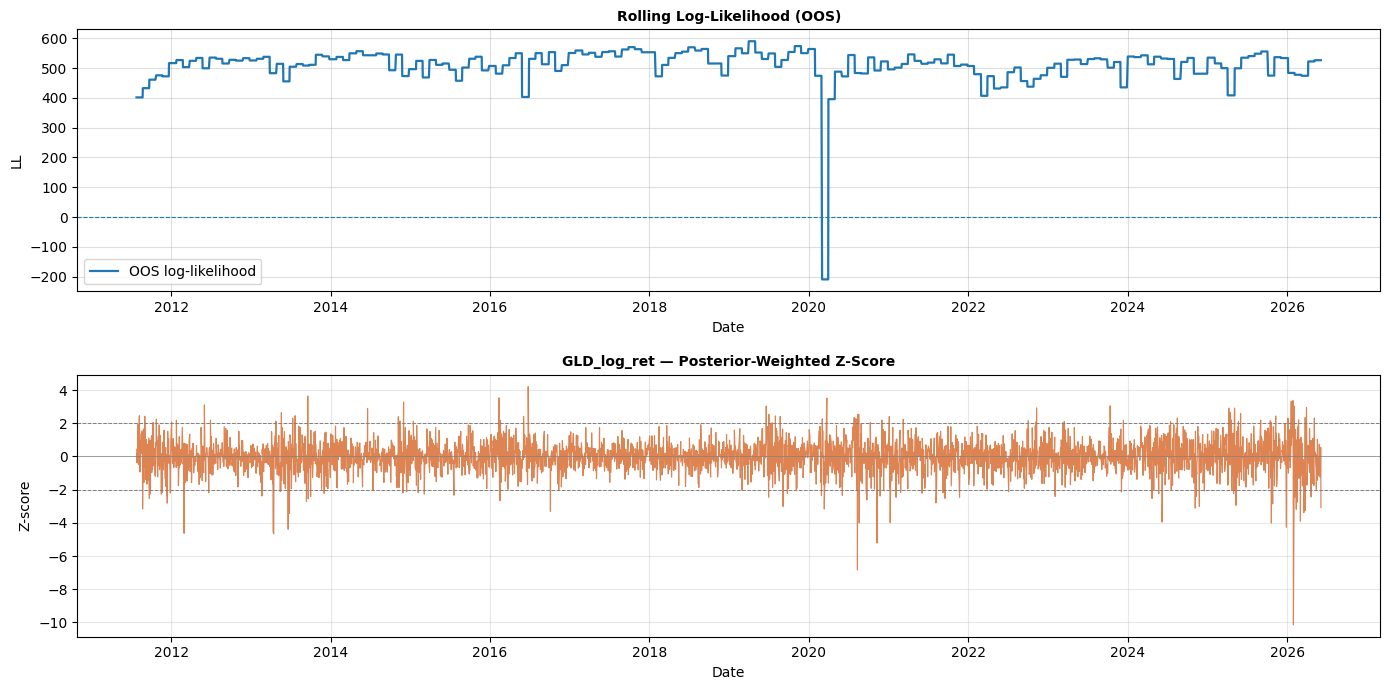

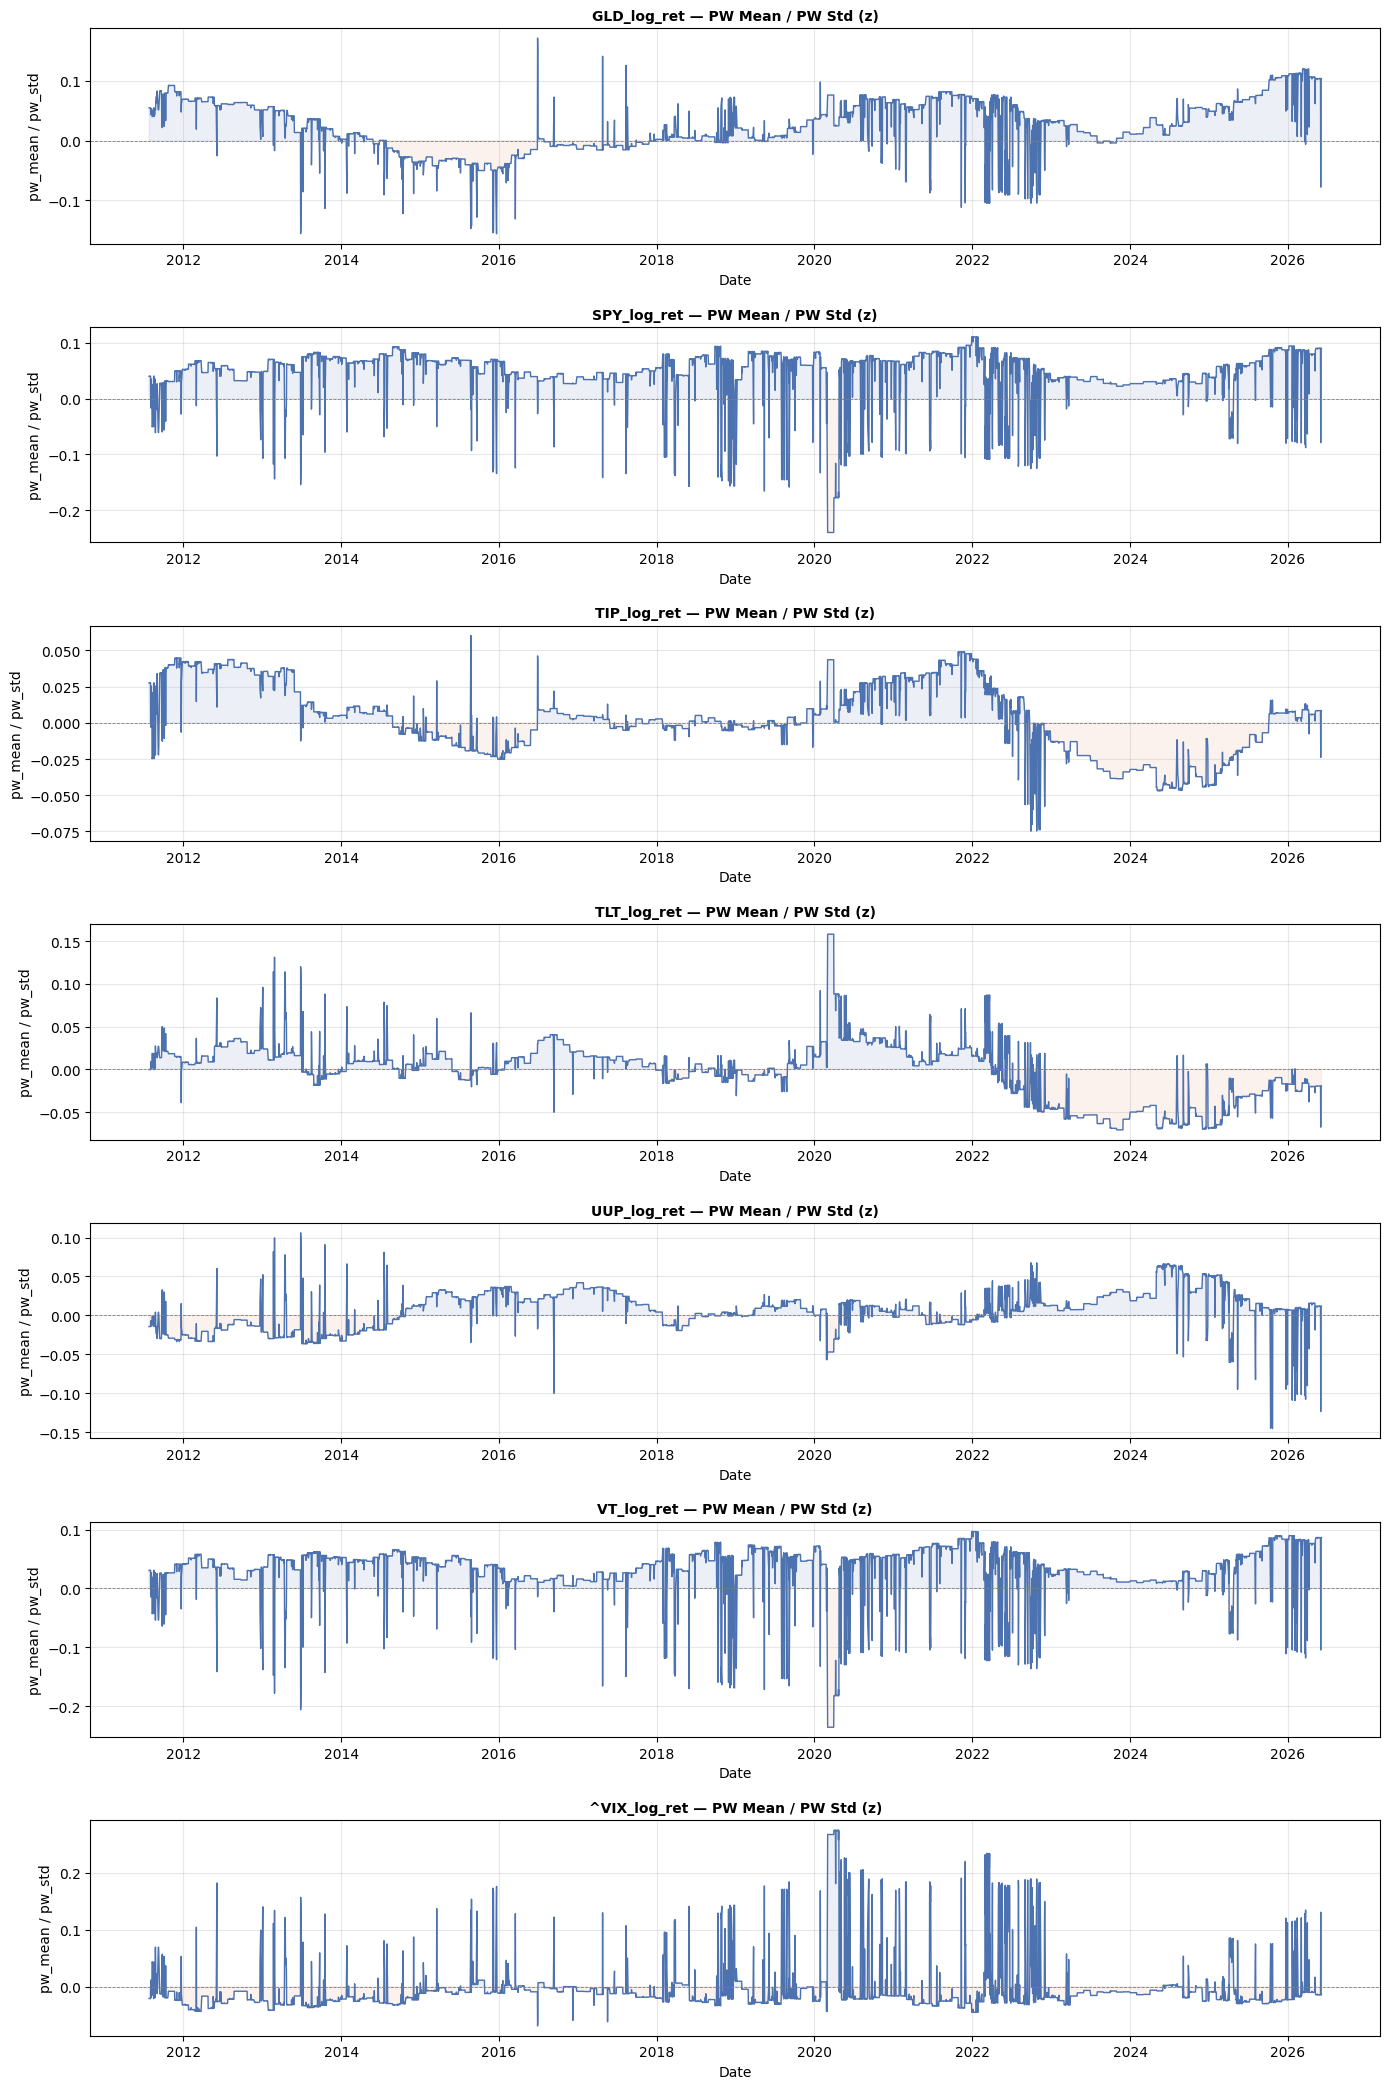

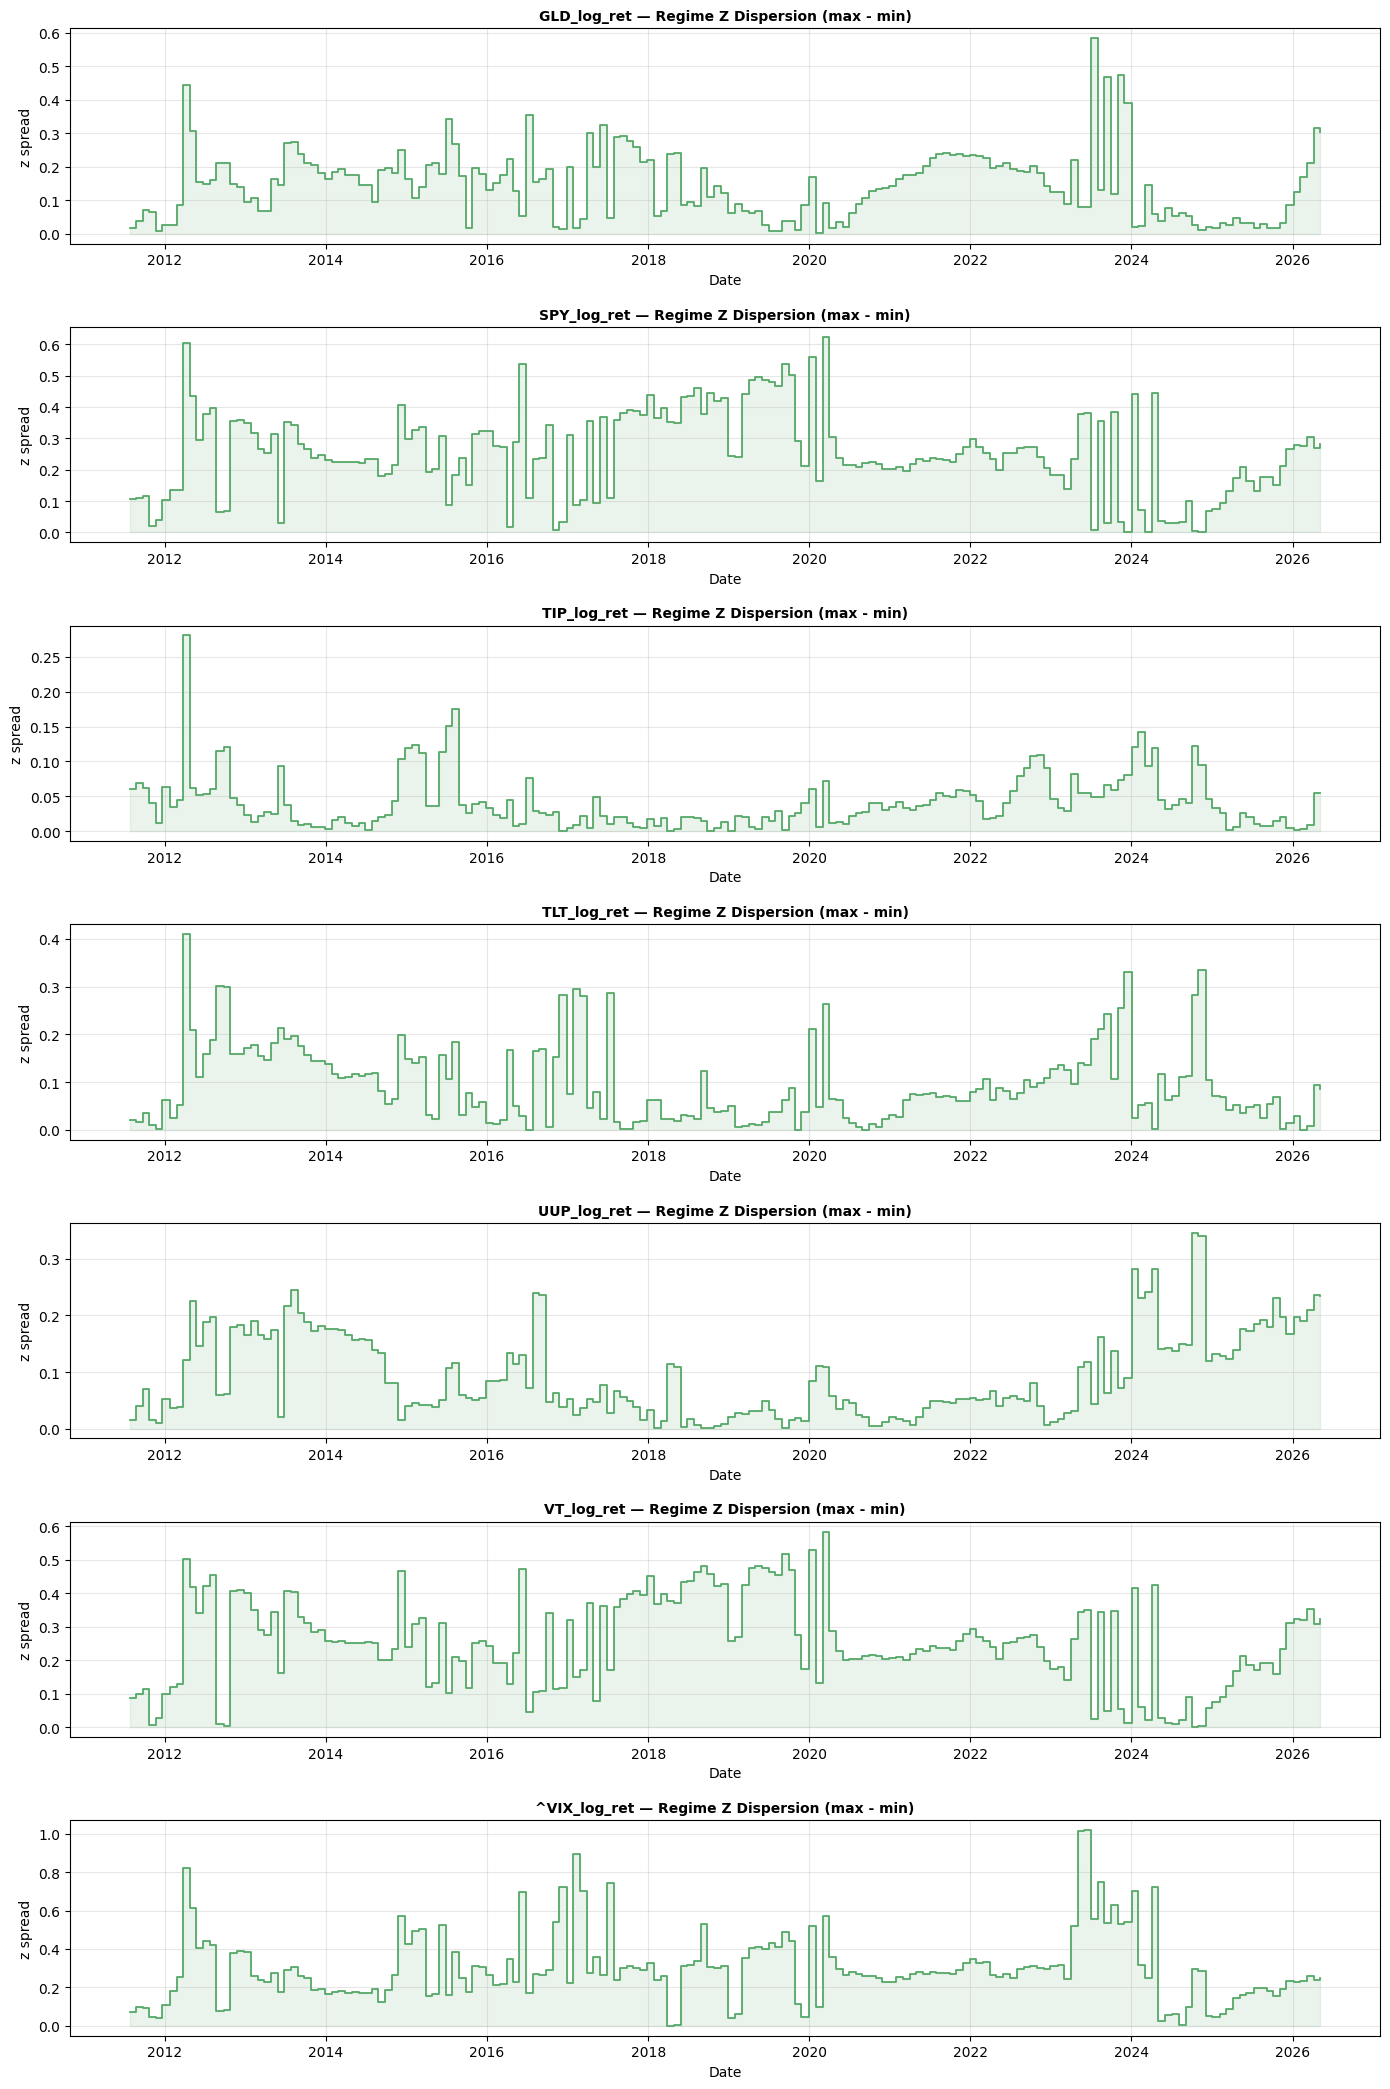

In [ ]:
def _setup_axes(n_rows, figsize_per_asset):
    fig, axes = plt.subplots(
        n_rows, 1,
        figsize=(figsize_per_asset[0], figsize_per_asset[1] * n_rows),
        sharex=True,
    )
    if n_rows == 1:
        axes = [axes]
    return fig, axes


def _plot_log_likelihood(ax, results):
    ax.plot(results.index, results["log_likelihood"], linewidth=1.6, label="OOS log-likelihood")
    ax.axhline(0, linestyle="--", linewidth=0.8)
    ax.set_title("Rolling Log-Likelihood (OOS)", fontsize=10, fontweight="bold")
    ax.set_ylabel("LL")
    ax.grid(alpha=0.4)
    ax.legend()

def plot_rolling_hmm(
    results: pd.DataFrame,
    returns: pd.DataFrame,
    mode: str = "bands",          # "bands" (error +/- n_sigma) or "z" (z-score)
    k: int = None,
    figsize_per_asset=(14, 3.5),
    n_sigma: float = 1.0,
    z_band: float = 2.0,
    max_assets: int = None,
) -> plt.Figure:

    if mode not in ("bands", "z"):
        raise ValueError(f"mode must be 'bands' or 'z', got {mode!r}")

    if k is not None:
        results = results[results["k"] == k]
    elif results["k"].nunique() > 1:
        raise ValueError(
            f"results has multiple k values {sorted(results['k'].unique())}; pass k=... to select one"
        )

    assets = returns.columns.tolist()
    if max_assets is not None:
        assets = assets[:max_assets]

    n_rows = 1 + len(assets)
    fig, axes = plt.subplots(n_rows, 1, figsize=(figsize_per_asset[0], figsize_per_asset[1] * n_rows), sharex=True)
    if n_rows == 1:
        axes = [axes]

    ax = axes[0]
    ax.plot(results.index, results["log_likelihood"], linewidth=1.6, label="OOS log-likelihood")
    ax.axhline(0, linestyle="--", linewidth=0.8)
    ax.set_title("Rolling Log-Likelihood (OOS)", fontsize=10, fontweight="bold")
    ax.set_ylabel("LL")
    ax.grid(alpha=0.4)
    ax.legend()

    for i, asset in enumerate(assets):
        ax = axes[i + 1]

        if mode == "bands":
            r = results[f"realized_{asset}"]
            mu = results[f"pw_mean_{asset}"]
            sigma = results[f"pw_std_{asset}"]
            y = r - mu

            ax.plot(results.index, y, linewidth=0.9, label="Realized - PW mean")
            ax.fill_between(results.index, n_sigma * sigma, -n_sigma * sigma,
                             alpha=0.15, label=f"±{n_sigma}σ (PW)")
            ax.axhline(0, linewidth=0.8)
            ax.set_title(f"{asset} — HMM Calibration", fontsize=10, fontweight="bold")
            ax.set_ylabel("Error")
            ax.legend(fontsize=7)

        else:  # mode == "z"
            z = results[f"z_{asset}"]

            ax.plot(results.index, z, linewidth=0.8, color="#DD8452")
            ax.fill_between(results.index, z, 0, where=z >= 0, alpha=0.10, color="#DD8452")
            ax.fill_between(results.index, z, 0, where=z < 0, alpha=0.10, color="#4C72B0")
            ax.axhline(z_band, color="grey", linestyle="--", linewidth=0.7)
            ax.axhline(-z_band, color="grey", linestyle="--", linewidth=0.7)
            ax.axhline(0, color="grey", linewidth=0.5)
            ax.set_title(f"{asset} — Posterior-Weighted Z-Score", fontsize=10, fontweight="bold")
            ax.set_ylabel("Z-score")

        ax.grid(alpha=0.3)

    for ax in axes:
      ax.set_xlabel("Date")
      ax.tick_params(axis="x", labelbottom=True)
    plt.tight_layout(h_pad=1.5)
    plt.show()
    return fig


def plot_pw_mean_std(
    results: pd.DataFrame,
    assets: list,
    k: int = None,
    figsize_per_asset: tuple = (14, 3.0),
) -> plt.Figure:

    if k is not None:
        results = results[results["k"] == k]
    elif results["k"].nunique() > 1:
        raise ValueError(
            f"results has multiple k values {sorted(results['k'].unique())}; pass k=... to select one"
        )

    n_assets = len(assets)
    fig, axes = plt.subplots(n_assets, 1, figsize=(figsize_per_asset[0], figsize_per_asset[1] * n_assets), sharex=True)
    if n_assets == 1:
        axes = [axes]

    for ax, asset in zip(axes, assets):
        z = results[f"pw_mean_{asset}"] / results[f"pw_std_{asset}"]
        d = pd.to_datetime(results.index)

        ax.plot(d, z, color="#4C72B0", linewidth=1.0)
        ax.fill_between(d, z, 0, where=z >= 0, alpha=0.10, color="#4C72B0")
        ax.fill_between(d, z, 0, where=z < 0, alpha=0.10, color="#DD8452")

        ax.axhline(0, color="grey", linewidth=0.6, linestyle="--")
        ax.set_title(f"{asset} — PW Mean / PW Std (z)", fontsize=10, fontweight="bold")
        ax.set_ylabel("pw_mean / pw_std")
        ax.grid(alpha=0.3)

    for ax in axes:
      ax.set_xlabel("Date")
      ax.tick_params(axis="x", labelbottom=True)
    plt.tight_layout(h_pad=1.5)
    plt.show()
    return fig


def plot_regime_dispersion(
    state_params: pd.DataFrame,
    assets: list,
    k: int = None,
    figsize_per_asset: tuple = (14, 3.0),
) -> plt.Figure:

    if k is not None:
        state_params = state_params[state_params["k"] == k]
    elif state_params["k"].nunique() > 1:
        raise ValueError(
            f"state_params has multiple k values {sorted(state_params['k'].unique())}; pass k=... to select one"
        )

    n_assets = len(assets)
    fig, axes = plt.subplots(n_assets, 1, figsize=(figsize_per_asset[0], figsize_per_asset[1] * n_assets), sharex=True)
    if n_assets == 1:
        axes = [axes]

    for ax, asset in zip(axes, assets):
        mean_col, std_col = f"mean_{asset}", f"std_{asset}"
        z_per_state = state_params[mean_col] / state_params[std_col]
        dispersion = (
            z_per_state.groupby(state_params["date"])
            .agg(lambda x: x.max() - x.min())
            .sort_index()
        )

        ax.plot(dispersion.index, dispersion.values, color="#55A868", linewidth=1.3, drawstyle="steps-post")
        ax.fill_between(dispersion.index, dispersion.values, 0, step="post", alpha=0.12, color="#55A868")

        ax.set_title(f"{asset} — Regime Z Dispersion (max - min)", fontsize=10, fontweight="bold")
        ax.set_ylabel("z spread")
        ax.grid(alpha=0.3)

    for ax in axes:
      ax.set_xlabel("Date")
      ax.tick_params(axis="x", labelbottom=True)
    plt.tight_layout(h_pad=1.5)
    plt.show()
    return fig

_ = plot_rolling_hmm(results, df_pandas, mode="z", k=2, max_assets=1)
_ = plot_pw_mean_std(results, assets=df_pandas.columns.tolist(), k=2)
_ = plot_regime_dispersion(state_params, assets=df_pandas.columns.tolist(), k=2)

Backtest

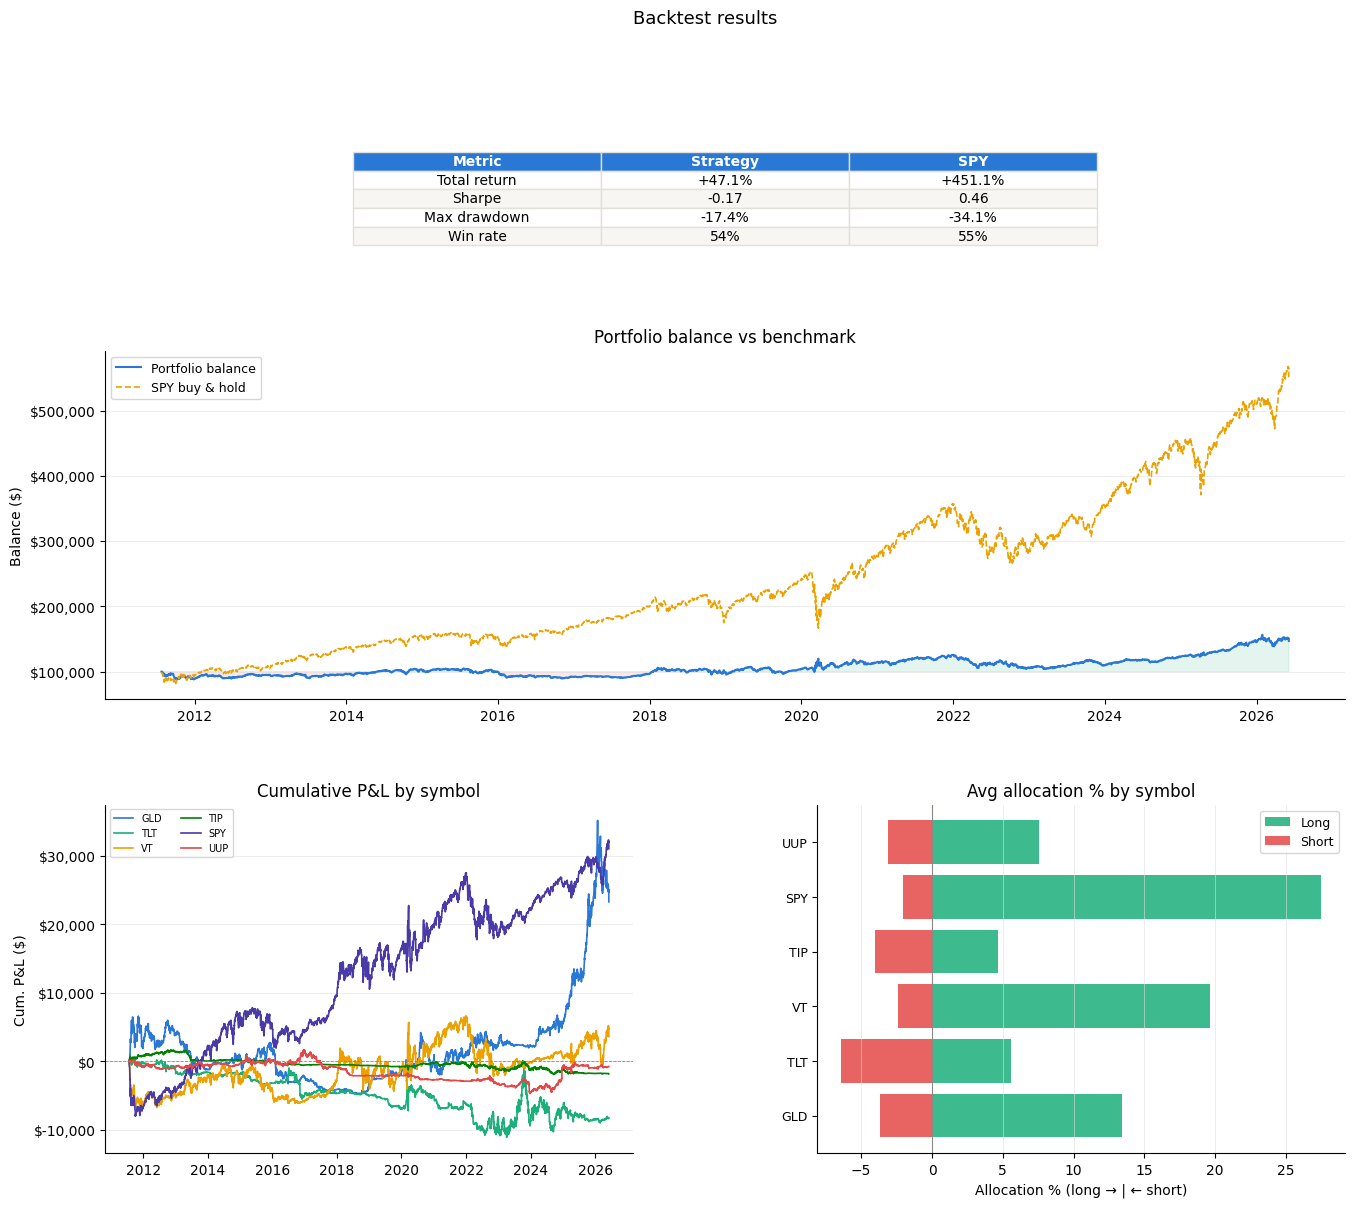

In [ ]:
def run_backtest(df, starting_balance=100_000, target_pct=100, min_signal=0.0,
                 symbols=None, mode='long_only', start_date=None, end_date=None):

    df = df.loc[start_date:end_date]

    all_symbols = [re.sub(r'^z_(.+)_log_ret$', r'\1', c)
                   for c in df.columns if c.startswith('z_') and c.endswith('_log_ret')]
    symbols = [s for s in (symbols or all_symbols) if s in all_symbols]

    results = []
    balance = starting_balance

    for date, row in df.iterrows():
        signal = {}
        for s in symbols:
            std = row[f'pw_std_{s}_log_ret']
            signal[s] = row[f'pw_mean_{s}_log_ret'] / std if std > 1e-10 else 0.0

        active = {s: v for s, v in signal.items() if abs(v) >= min_signal}
        if mode == 'long_only':
            active = {s: v for s, v in active.items() if v > 0}

        sum_sig = sum(abs(v) for v in active.values()) or 1

        day_pnl, positions = 0.0, {}
        for s, sig in active.items():
            alloc_pct  = (abs(sig) / sum_sig) * target_pct
            dollar_pos = balance * (alloc_pct / 100)
            side       = 1 if (mode == 'long_only' or sig > 0) else -1
            pnl        = dollar_pos * side * (np.exp(row[f'realized_{s}_log_ret']) - 1)
            day_pnl   += pnl
            positions[s] = dict(side='long' if side > 0 else 'short',
                                 alloc_pct=alloc_pct, dollar_pos=dollar_pos,
                                 realized=row[f'realized_{s}_log_ret'], pnl=pnl)

        balance += day_pnl

        results.append(dict(date=date, day_pnl=day_pnl, balance=balance,
                            gross_exposure_pct=sum(p['alloc_pct'] for p in positions.values()),
                            n_positions=len(positions), positions=positions))

    out = pd.DataFrame(results).set_index('date')
    out['cum_pnl']       = out['balance'] - starting_balance
    out['daily_ret_pct'] = out['day_pnl'] / out['balance'].shift(1).fillna(starting_balance) * 100
    return out

def plot_backtest(out, df, starting_balance=100_000, benchmark_symbol='SPY'):
    symbols = list({s for p in out['positions'] for s in p.keys()})

    fig = plt.figure(figsize=(16, 13))
    gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.4, wspace=0.35, height_ratios=[0.8, 3, 3])

    # --- compute everything needed for both the table and the balance chart first ---
    bm_rets    = df.loc[out.index, f'realized_{benchmark_symbol}_log_ret']
    bm_balance = starting_balance * np.exp(bm_rets.cumsum())

    active_days = out[out['n_positions'] > 0]
    daily_ret   = active_days['daily_ret_pct'] / 100
    rf_daily    = 0.05 / 252
    excess      = daily_ret - rf_daily
    sharpe      = (excess.mean() / excess.std()) * np.sqrt(252)
    max_dd      = ((out['balance'] / out['balance'].cummax()) - 1).min() * 100
    win_rate    = (active_days['day_pnl'] > 0).mean() * 100
    total_ret   = (out['balance'].iloc[-1] / starting_balance - 1) * 100

    bm_daily_ret_full = np.exp(bm_rets) - 1
    bm_excess   = bm_daily_ret_full - rf_daily
    bm_sharpe   = (bm_excess.mean() / bm_excess.std()) * np.sqrt(252)
    bm_max_dd   = ((bm_balance / bm_balance.cummax()) - 1).min() * 100
    bm_win_rate = (bm_daily_ret_full > 0).mean() * 100
    bm_ret      = (bm_balance.iloc[-1] / starting_balance - 1) * 100

    # 1. comparison table — FIRST, top of figure
    ax_tbl = fig.add_subplot(gs[0, :])
    ax_tbl.axis('off')
    row_labels = ['Total return', 'Sharpe', 'Max drawdown', 'Win rate']
    strat_vals = [f'{total_ret:+.1f}%', f'{sharpe:.2f}', f'{max_dd:.1f}%', f'{win_rate:.0f}%']
    bm_vals    = [f'{bm_ret:+.1f}%', f'{bm_sharpe:.2f}', f'{bm_max_dd:.1f}%', f'{bm_win_rate:.0f}%']
    table_data = [[lbl, sv, bv] for lbl, sv, bv in zip(row_labels, strat_vals, bm_vals)]

    table = ax_tbl.table(
        cellText=table_data,
        colLabels=['Metric', 'Strategy', benchmark_symbol],
        cellLoc='center',
        colLoc='center',
        loc='center',
        bbox=[0.2, 0.0, 0.6, 1.0]
    )
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    for (r, c), cell in table.get_celld().items():
        cell.set_edgecolor('#e1e0d9')
        if r == 0:
            cell.set_facecolor('#2a78d6')
            cell.set_text_props(color='white', weight='bold')
        else:
            cell.set_facecolor('#f7f6f2' if r % 2 == 0 else 'white')

    # 2. balance chart — SECOND
    ax1 = fig.add_subplot(gs[1, :])
    ax1.plot(out.index, out['balance'], color='#2a78d6', linewidth=1.5, label='Portfolio balance')
    ax1.fill_between(out.index, starting_balance, out['balance'],
                     where=out['balance'] >= starting_balance, alpha=0.12, color='#1baf7a')
    ax1.fill_between(out.index, starting_balance, out['balance'],
                     where=out['balance'] < starting_balance, alpha=0.12, color='#e34948')
    ax1.plot(out.index, bm_balance, color='#eda100', linewidth=1.2, linestyle='--', label=f'{benchmark_symbol} buy & hold')
    ax1.set_title('Portfolio balance vs benchmark', fontsize=12)
    ax1.set_ylabel('Balance ($)')
    ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
    ax1.legend(fontsize=9)
    ax1.grid(axis='y', linewidth=0.4, color='#e1e0d9')
    ax1.spines[['top','right']].set_visible(False)

    # 3. per-symbol cumulative P&L
    ax2 = fig.add_subplot(gs[2, 0])
    palette = ['#2a78d6','#1baf7a','#eda100','#008300','#4a3aa7','#e34948','#e87ba4','#eb6834','#888780']
    sym_pnl = {s: [] for s in symbols}
    for _, row in out.iterrows():
        for s in symbols:
            p = row['positions'].get(s, {})
            sym_pnl[s].append(p.get('pnl', 0))
    for i, s in enumerate(symbols):
        cum = np.cumsum(sym_pnl[s])
        ax2.plot(out.index, cum, label=s, color=palette[i % len(palette)], linewidth=1.2)
    ax2.axhline(0, color='#888780', linewidth=0.6, linestyle='--')
    ax2.set_title('Cumulative P&L by symbol', fontsize=12)
    ax2.set_ylabel('Cum. P&L ($)')
    ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
    ax2.legend(fontsize=7, ncol=2)
    ax2.grid(axis='y', linewidth=0.4, color='#e1e0d9')
    ax2.spines[['top','right']].set_visible(False)

    # 4. average allocation % by symbol (long vs short)
    ax3 = fig.add_subplot(gs[2, 1])
    long_alloc  = {s: [] for s in symbols}
    short_alloc = {s: [] for s in symbols}
    for _, row in out.iterrows():
        for s in symbols:
            p = row['positions'].get(s, {})
            if p.get('side') == 'long':
                long_alloc[s].append(p.get('alloc_pct', 0))
                short_alloc[s].append(0)
            elif p.get('side') == 'short':
                short_alloc[s].append(p.get('alloc_pct', 0))
                long_alloc[s].append(0)
            else:
                long_alloc[s].append(0)
                short_alloc[s].append(0)
    avg_long  = [np.mean(long_alloc[s])  for s in symbols]
    avg_short = [-np.mean(short_alloc[s]) for s in symbols]
    x = np.arange(len(symbols))
    ax3.barh(x, avg_long,  color='#1baf7a', alpha=0.85, label='Long')
    ax3.barh(x, avg_short, color='#e34948', alpha=0.85, label='Short')
    ax3.set_yticks(x)
    ax3.set_yticklabels(symbols, fontsize=9)
    ax3.axvline(0, color='#888780', linewidth=0.8)
    ax3.set_title('Avg allocation % by symbol', fontsize=12)
    ax3.set_xlabel('Allocation % (long → | ← short)')
    ax3.legend(fontsize=9)
    ax3.grid(axis='x', linewidth=0.4, color='#e1e0d9')
    ax3.spines[['top','right']].set_visible(False)

    fig.suptitle('Backtest results', fontsize=13, y=0.99)
    plt.show()

selected_result = results[results["k"] == 2]
out = run_backtest(selected_result, mode='both', symbols=symbols_selected[:-1])
plot_backtest(out, selected_result)


Live

In [ ]:
def plot_states(summary: pd.DataFrame):

    last = summary.iloc[-1]

    state_cols = sorted([c for c in summary.columns if c.startswith("state_prob_")])
    next_cols  = sorted([c for c in summary.columns if c.startswith("next_state_prob_")])

    k = len(state_cols)

    current = np.array([last[c] for c in state_cols])
    nxt = np.array([last[c] for c in next_cols])

    x = np.arange(k)

    # consistent per-state colors
    cmap = plt.get_cmap("tab10")
    colors = [cmap(i) for i in range(k)]

    fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=False)

    # ── CURRENT ─────────────────────────────
    axes[0].bar(x, current, color=colors)
    axes[0].set_title("Current State Probabilities")
    axes[0].set_ylim(0, 1)
    axes[0].grid(axis="y", alpha=0.3)

    for i, v in enumerate(current):
        axes[0].text(i, v + 0.02, f"{v*100:.1f}%", ha="center", fontsize=9)

    # ── NEXT ────────────────────────────────
    axes[1].bar(x, nxt, color=colors)
    axes[1].set_title("Next State Probabilities")
    axes[1].set_ylim(0, 1)
    axes[1].grid(axis="y", alpha=0.3)

    for i, v in enumerate(nxt):
        axes[1].text(i, v + 0.02, f"{v*100:.1f}%", ha="center", fontsize=9)

    axes[1].set_xticks(x)
    axes[1].set_xticklabels([f"State {i}" for i in range(k)])

    plt.tight_layout()
    plt.show()


def plot_pw_signal_to_noise(df):

    row = df.iloc[0]

    mean_cols = [c for c in df.columns if c.startswith("pw_mean_")]
    symbols = [c.replace("pw_mean_", "") for c in mean_cols]

    means = np.array([row[f"pw_mean_{s}"] for s in symbols], dtype=float)
    stds  = np.array([row[f"pw_std_{s}"] for s in symbols], dtype=float)

    snr = means / (stds + 1e-12)

    order = np.argsort(snr)
    symbols = np.array(symbols)[order]
    snr = snr[order]

    x = np.arange(len(symbols))

    fig, ax = plt.subplots(figsize=(12, 5))

    ax.bar(x, snr, alpha=0.85)

    ax.axhline(0, color="black", linestyle=":", linewidth=1)

    ax.set_xticks(x)
    ax.set_xticklabels(symbols, rotation=90, ha="right")

    ax.set_ylabel("Z-score")
    ax.grid(axis="y", alpha=0.3)
    plt.title("Predicted State's (PW)")
    plt.tight_layout()
    plt.show()

def plot_pw_all_symbols(df):

    row = df.iloc[0]

    mean_cols = [c for c in df.columns if c.startswith("pw_mean_")]
    symbols = [c.replace("pw_mean_", "") for c in mean_cols]

    means = np.array([row[f"pw_mean_{s}"] for s in symbols], dtype=float)
    stds  = np.array([row[f"pw_std_{s}"] for s in symbols], dtype=float)

    order = np.argsort(means)

    symbols = np.array(symbols)[order]
    means = means[order]
    stds = stds[order]

    x = np.arange(len(symbols))

    fig, ax = plt.subplots(figsize=(12, 5))

    ax.bar(x, means, alpha=0.85)

    # symmetric uncertainty overlay (cleaner than bar+yerr)
    ax.errorbar(
        x,
        means,
        yerr=stds,
        fmt="none",
        ecolor="black",
        capsize=3,
        alpha=0.5
    )

    ax.axhline(0, color="black", linestyle=":", linewidth=1)

    ax.set_xticks(x)
    ax.set_xticklabels(symbols, rotation=90, ha="right")

    ax.set_ylabel("PW Mean")
    ax.grid(axis="y", alpha=0.3)

    plt.tight_layout()
    plt.show()


df = df_pandas.copy()
df.index = pd.to_datetime(df.index)

cutoff_date = pd.Timestamp("2026-06-23")

recent = df.loc[
    (df.index >= cutoff_date - pd.Timedelta(days=370)) &
    (df.index <= cutoff_date)
]


#model, summary, diag = run_live_hmm_wide(recent, k=2, n_restarts=1)
#display(summary.head())
#plot_pw_signal_to_noise(summary) #should be of next state instead
#plot_pw_all_symbols(summary)
#plot_states(summary)

## Tests

In [ ]:
results_list = {}
df_pandas = log_ret.to_pandas()
df_pandas["date"] = pd.to_datetime(df_pandas["date"])
df_pandas = df_pandas.set_index("date")

100%|██████████| 165/165 [00:49<00:00,  3.34it/s]


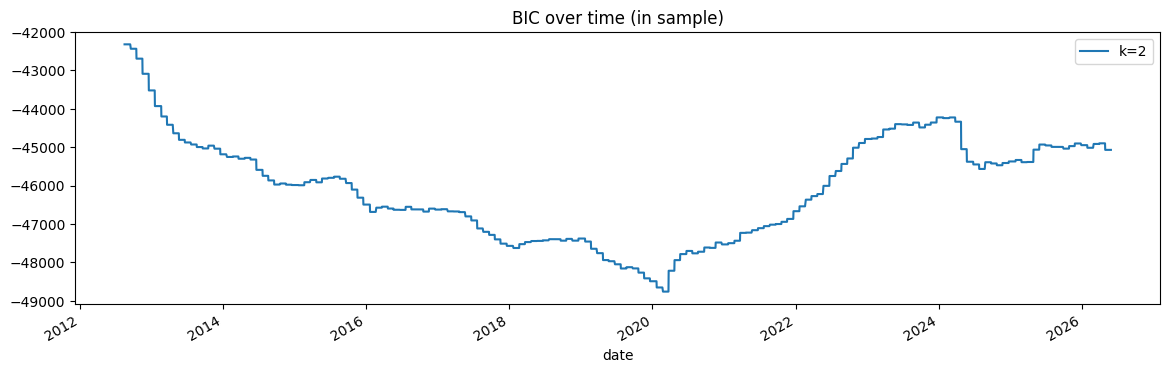

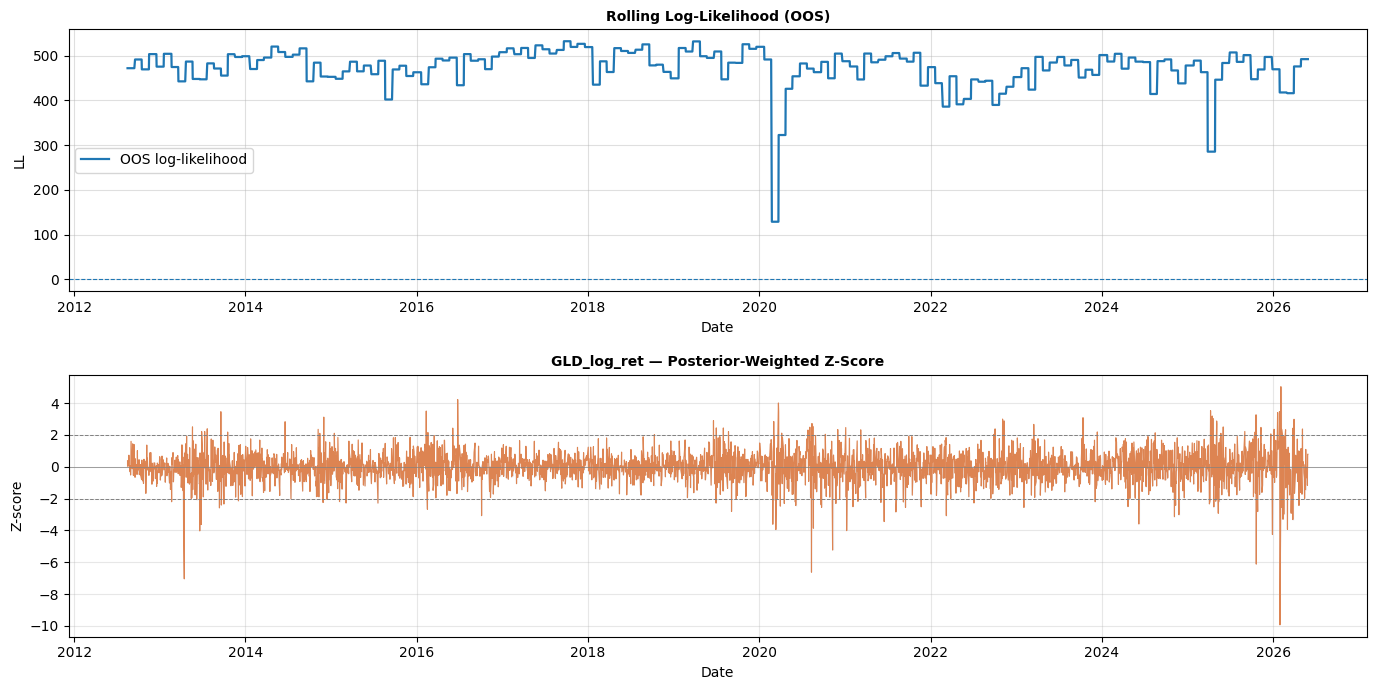

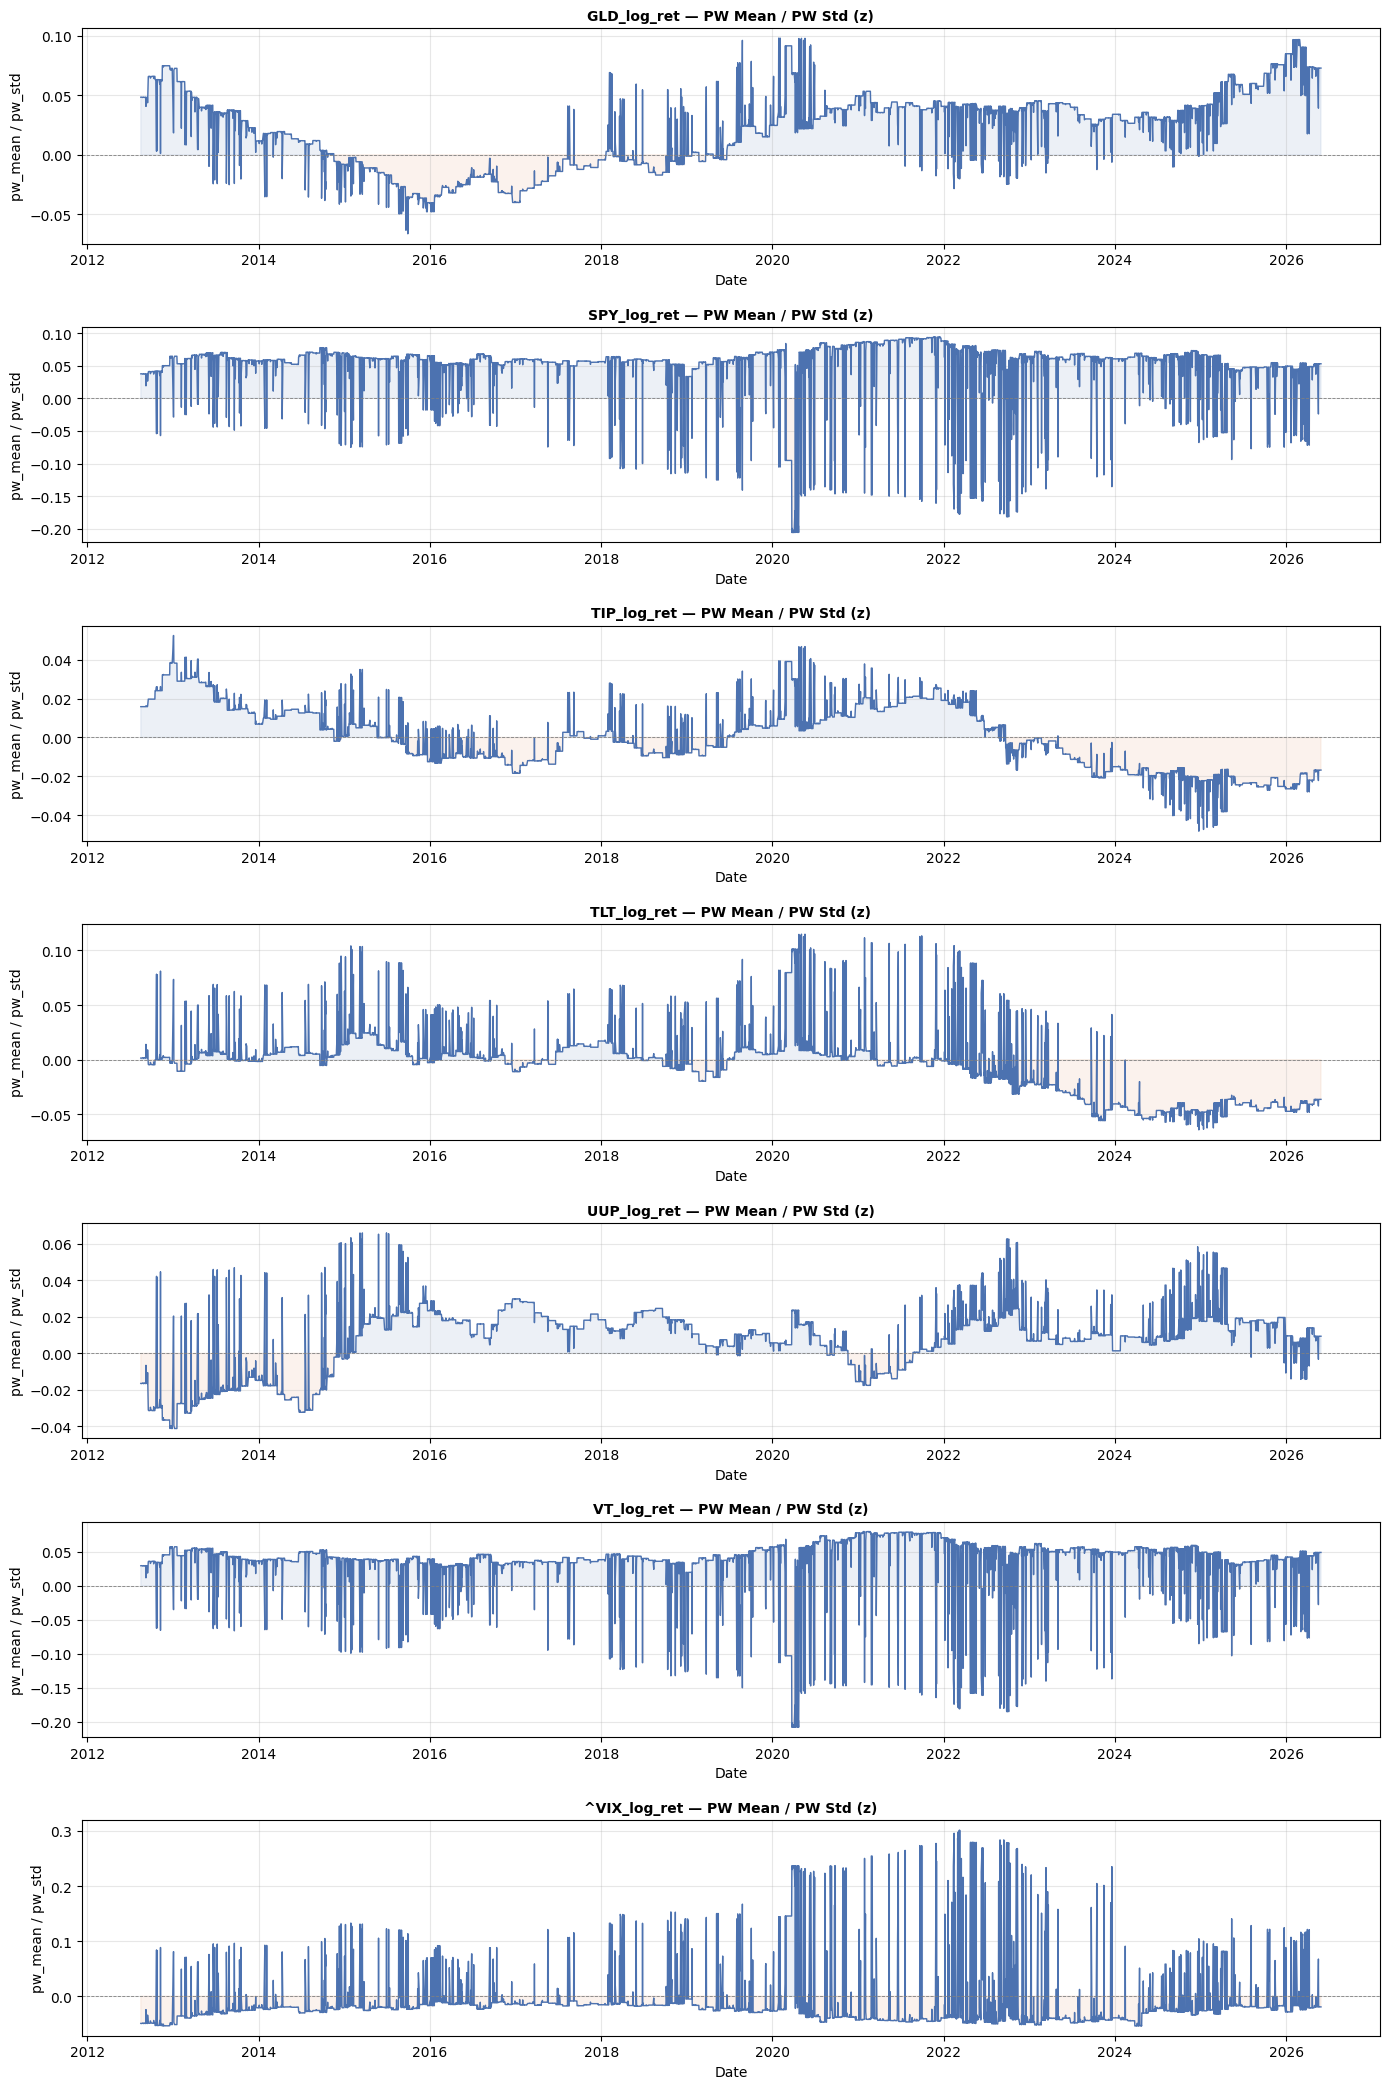

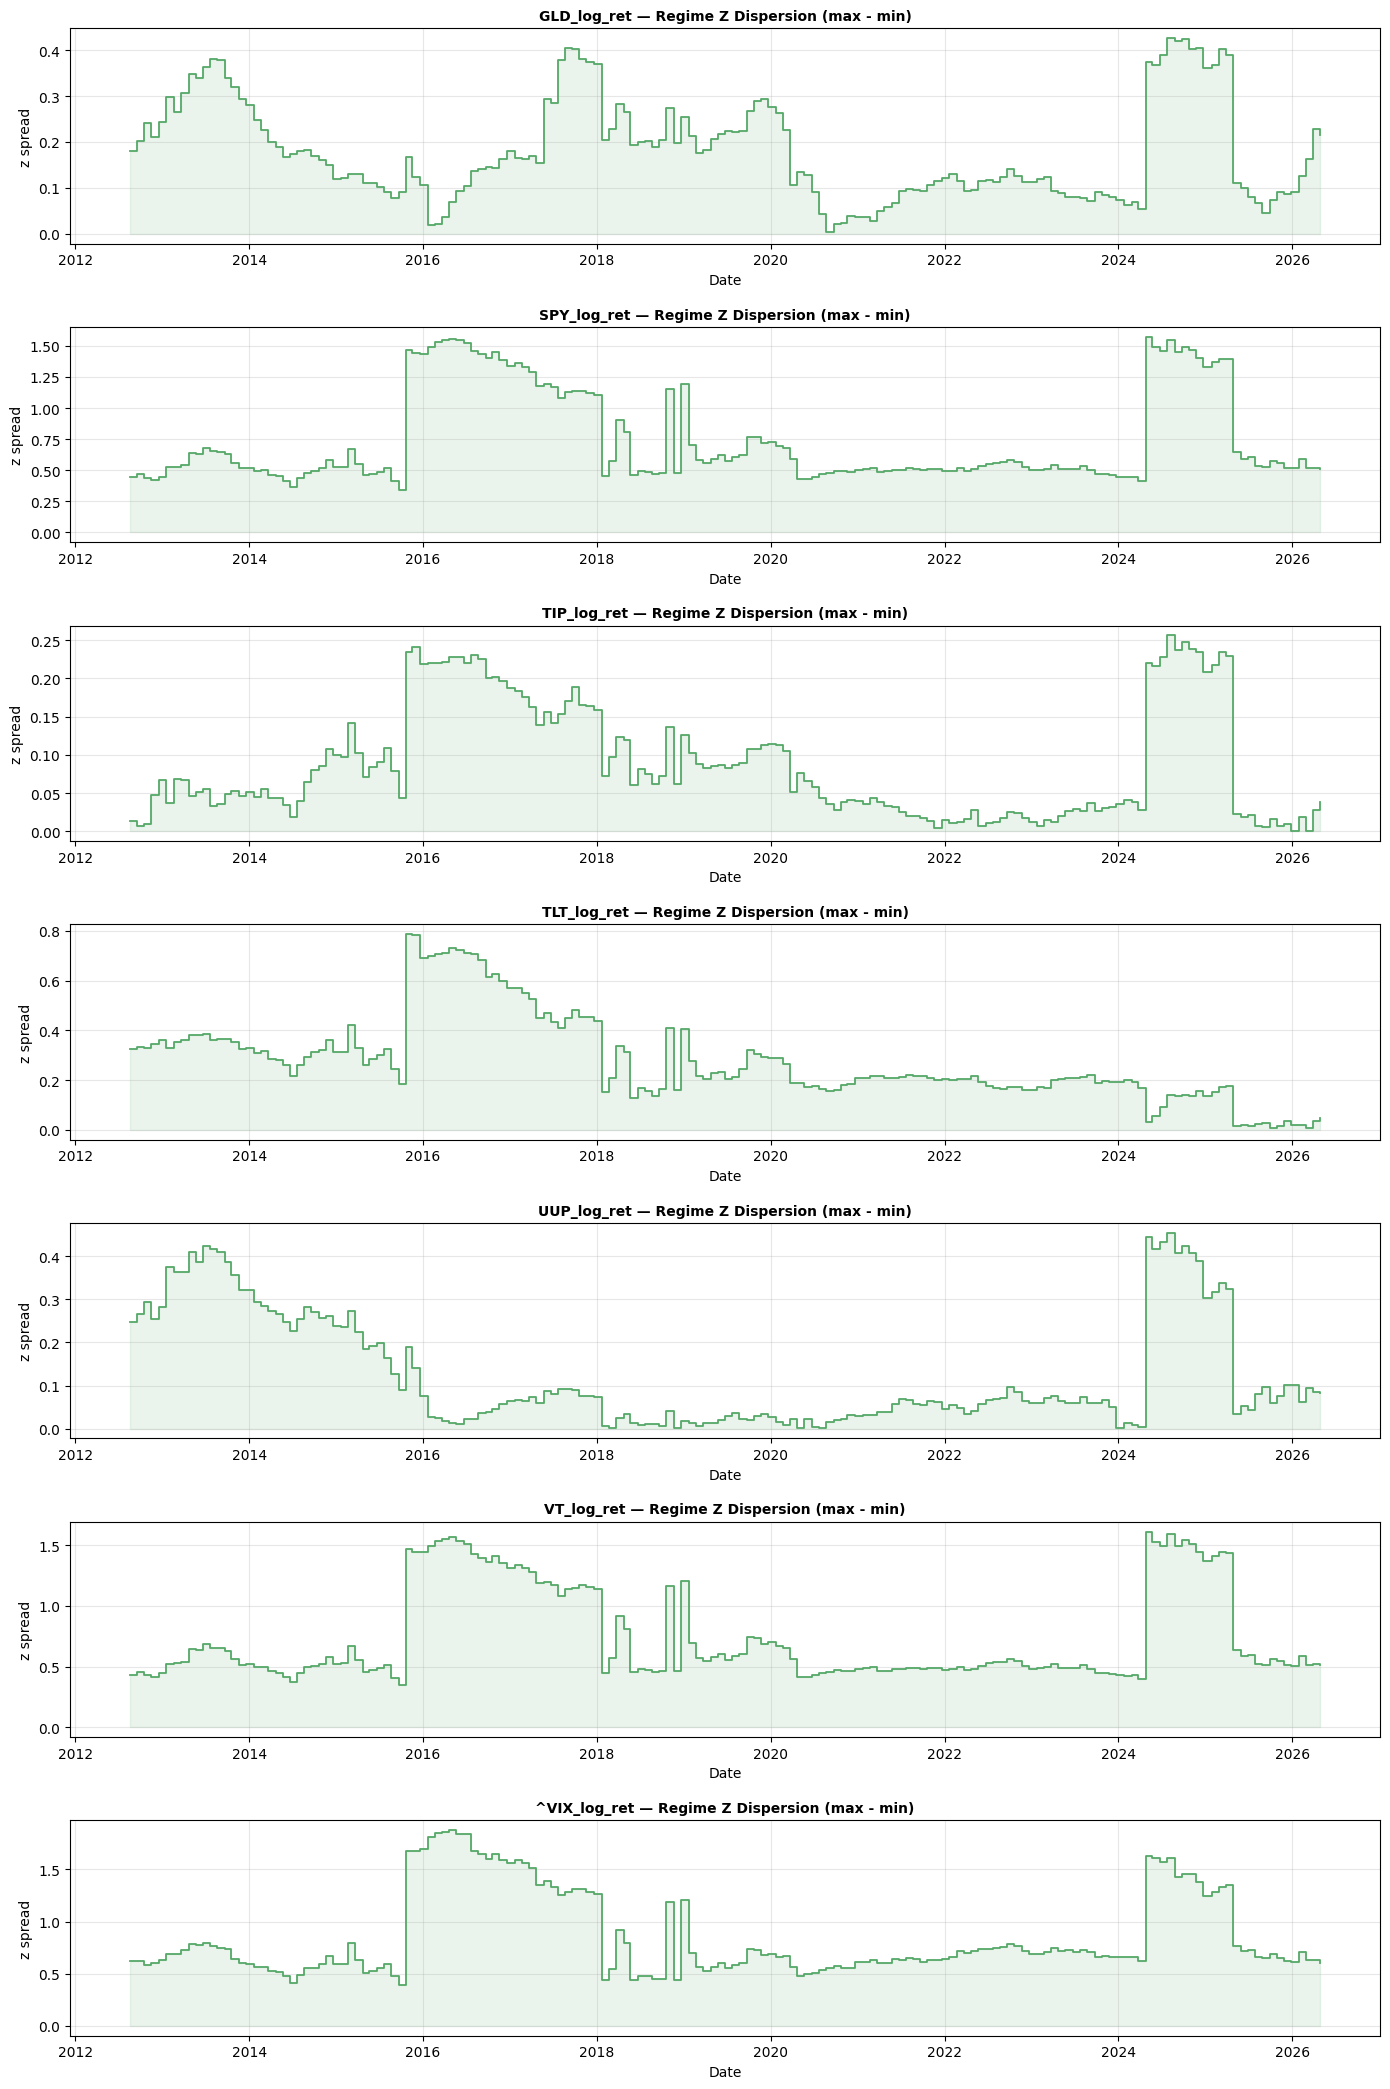

In [ ]:
results, state_params = run_rolling_hmm_wide(df_pandas, window=1024, step=21, n_states=[2],
                          covariance_type="diag", n_restarts=5, n_iter=500)
results_list[1] = results
plot_bics(results)
selected_result = results[results["k"] == 2]
_ = plot_rolling_hmm(results, df_pandas, mode="z", k=2, max_assets=1)
_ = plot_pw_mean_std(results, assets=df_pandas.columns.tolist(), k=2)
_ = plot_regime_dispersion(state_params, assets=df_pandas.columns.tolist(), k=2)
#doesn't account for transcation costs, etc

Long-short Macro Rotation

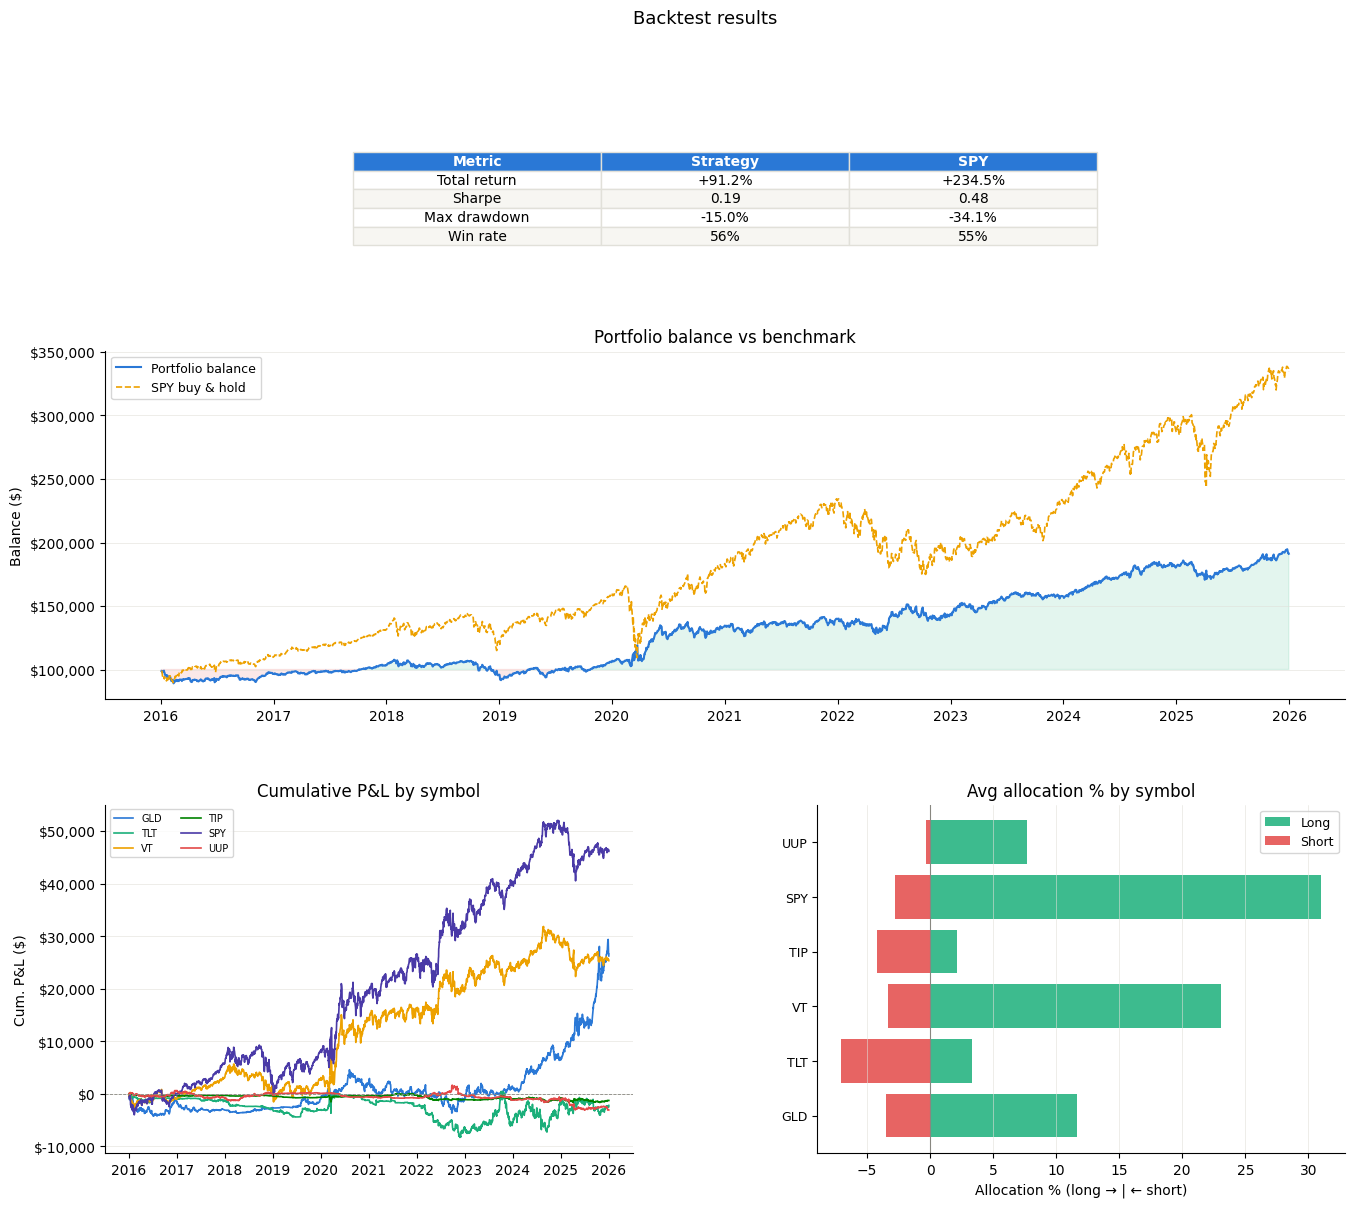

In [ ]:
out = run_backtest(selected_result, mode='both', start_date='2016-01-01', end_date='2026-01-01', symbols=symbols_selected[:-1])
plot_backtest(out, selected_result)

Long-Only Macro Rotation

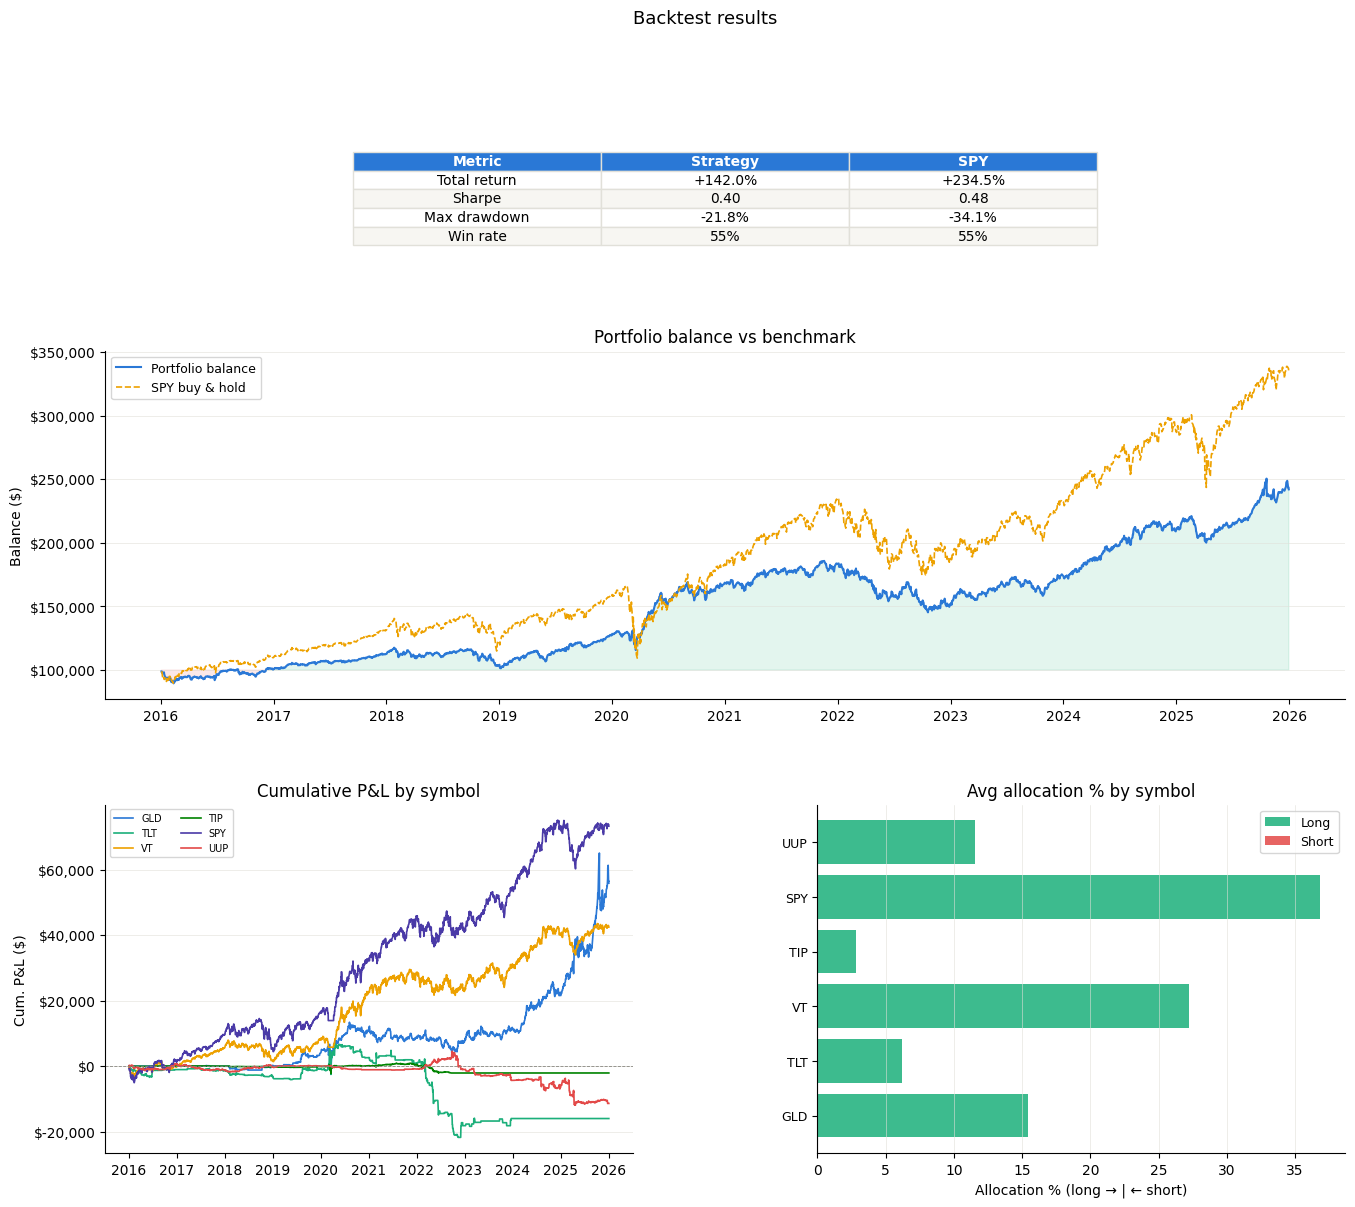

In [ ]:
results = results_list[1]
selected_result = results[results["k"] == 2]
out = run_backtest(selected_result, mode='long_only', start_date='2016-01-01', end_date='2026-01-01', symbols=symbols_selected[:-1])
plot_backtest(out, selected_result)

US Equities vs Gold Rotation

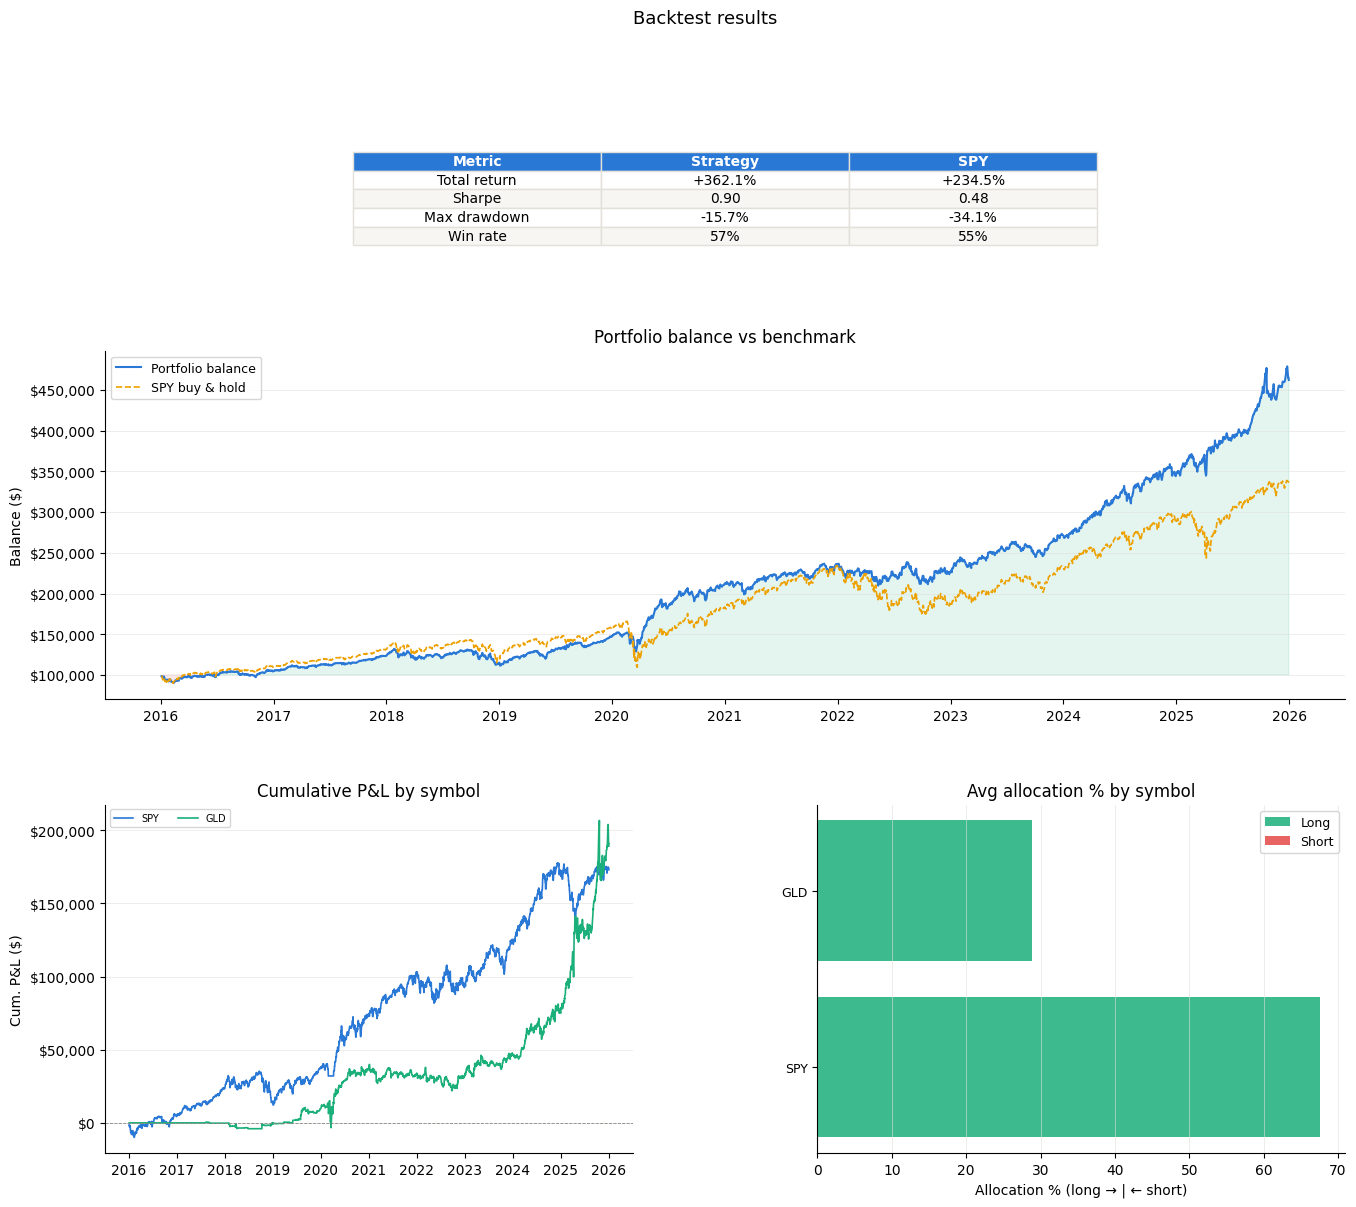

In [ ]:
results = results_list[1]
selected_result = results[results["k"] == 2]
out = run_backtest(selected_result, mode='long_only', start_date='2016-01-01', end_date='2026-01-01', symbols = ["SPY", "GLD"])
plot_backtest(out, selected_result)

Timing

VT


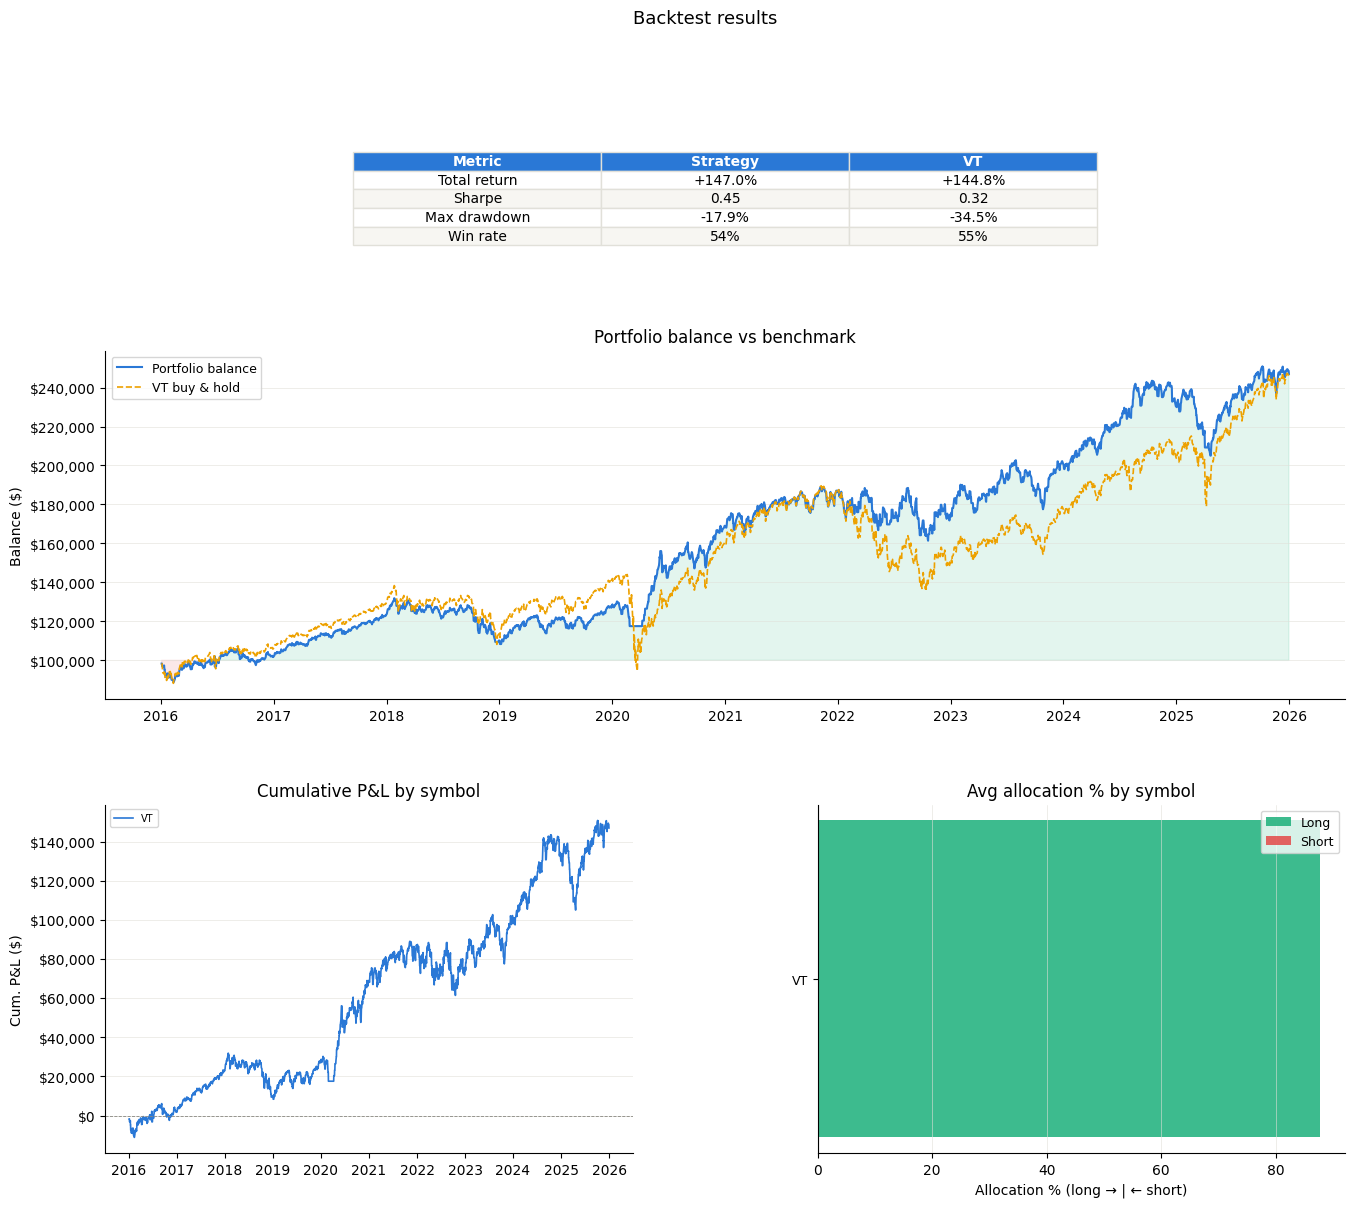

SPY


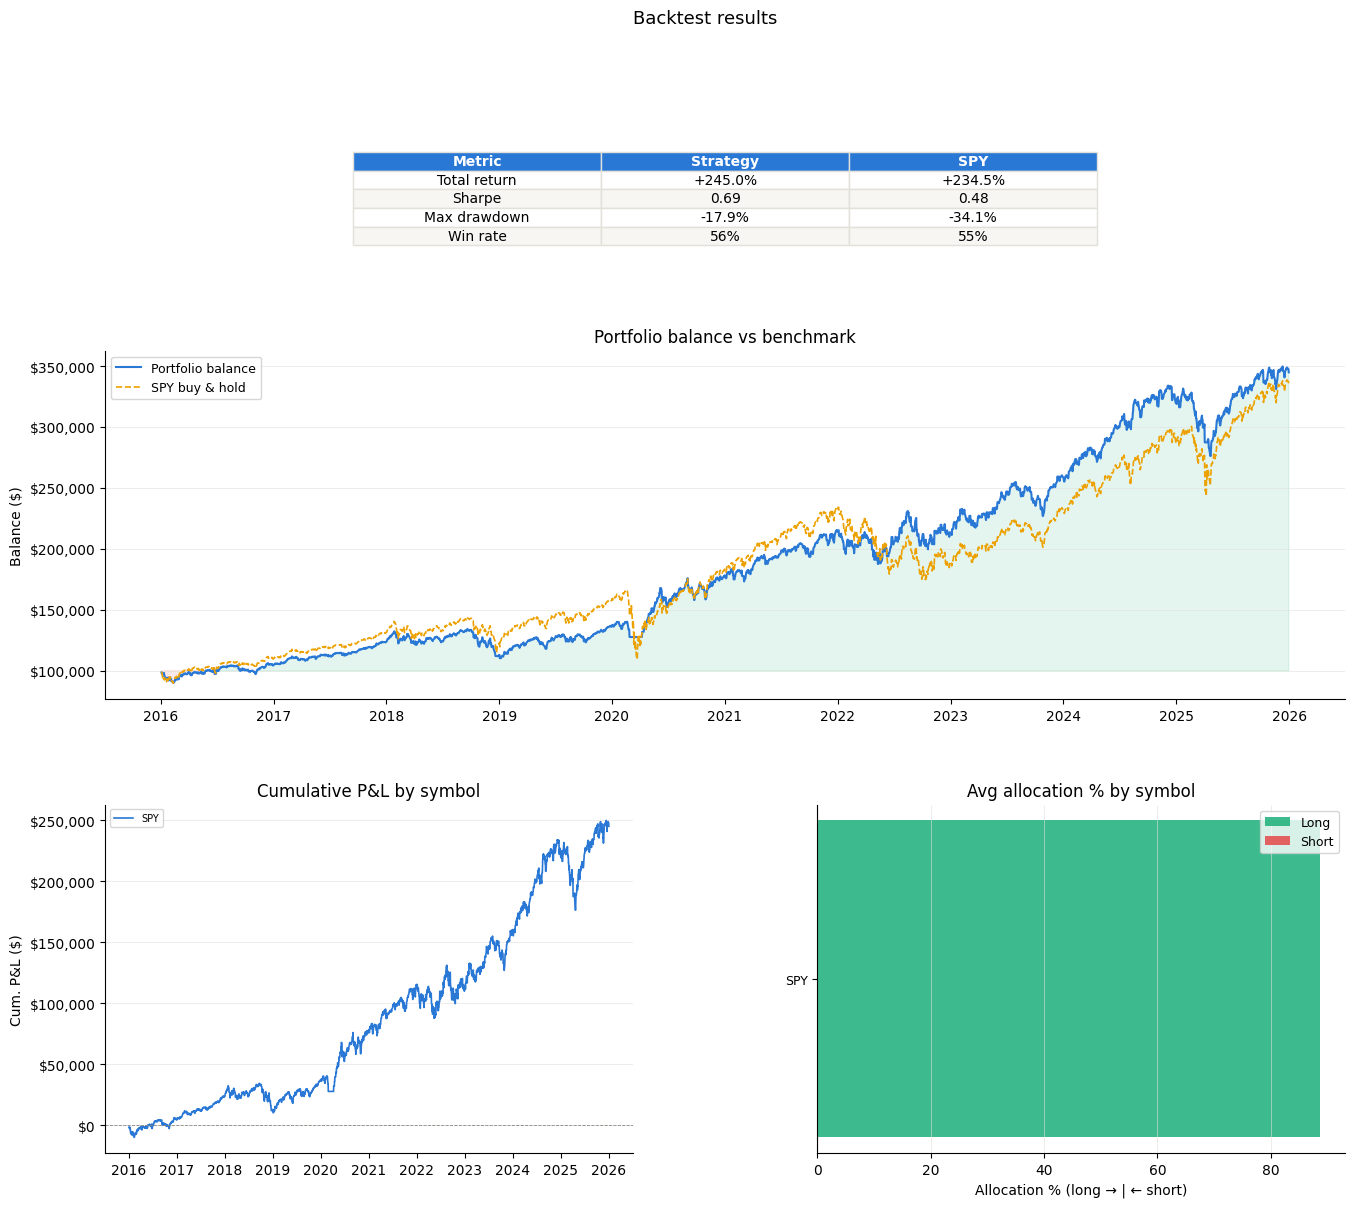

GLD


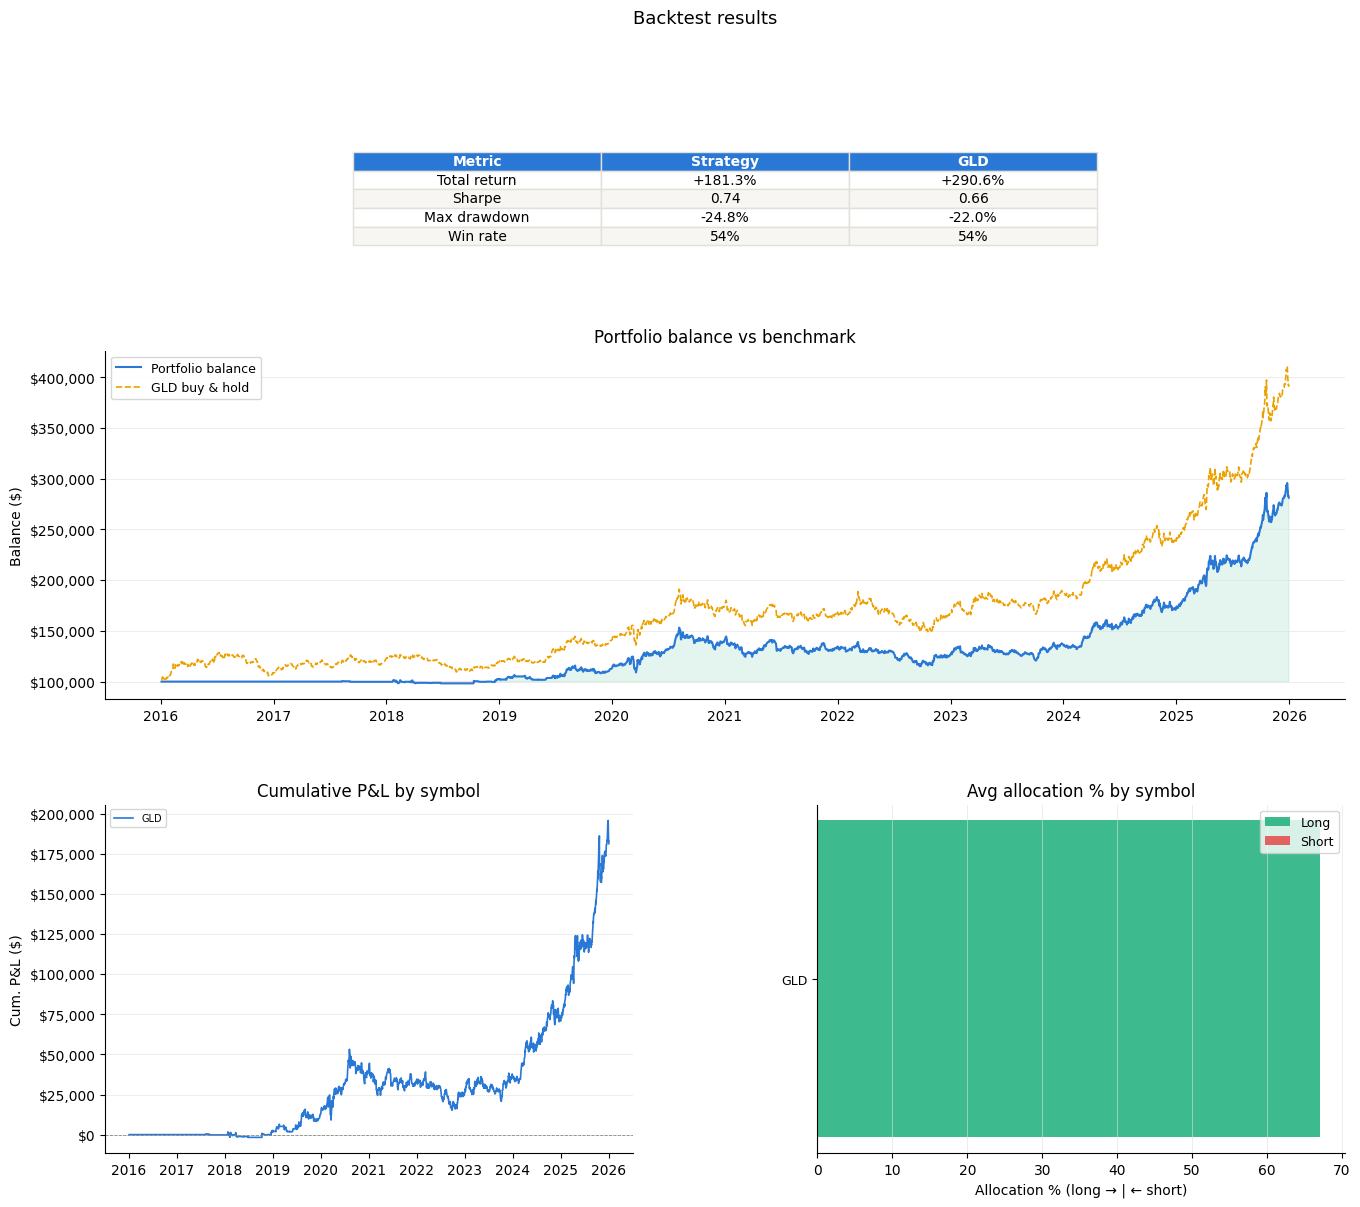

TLT


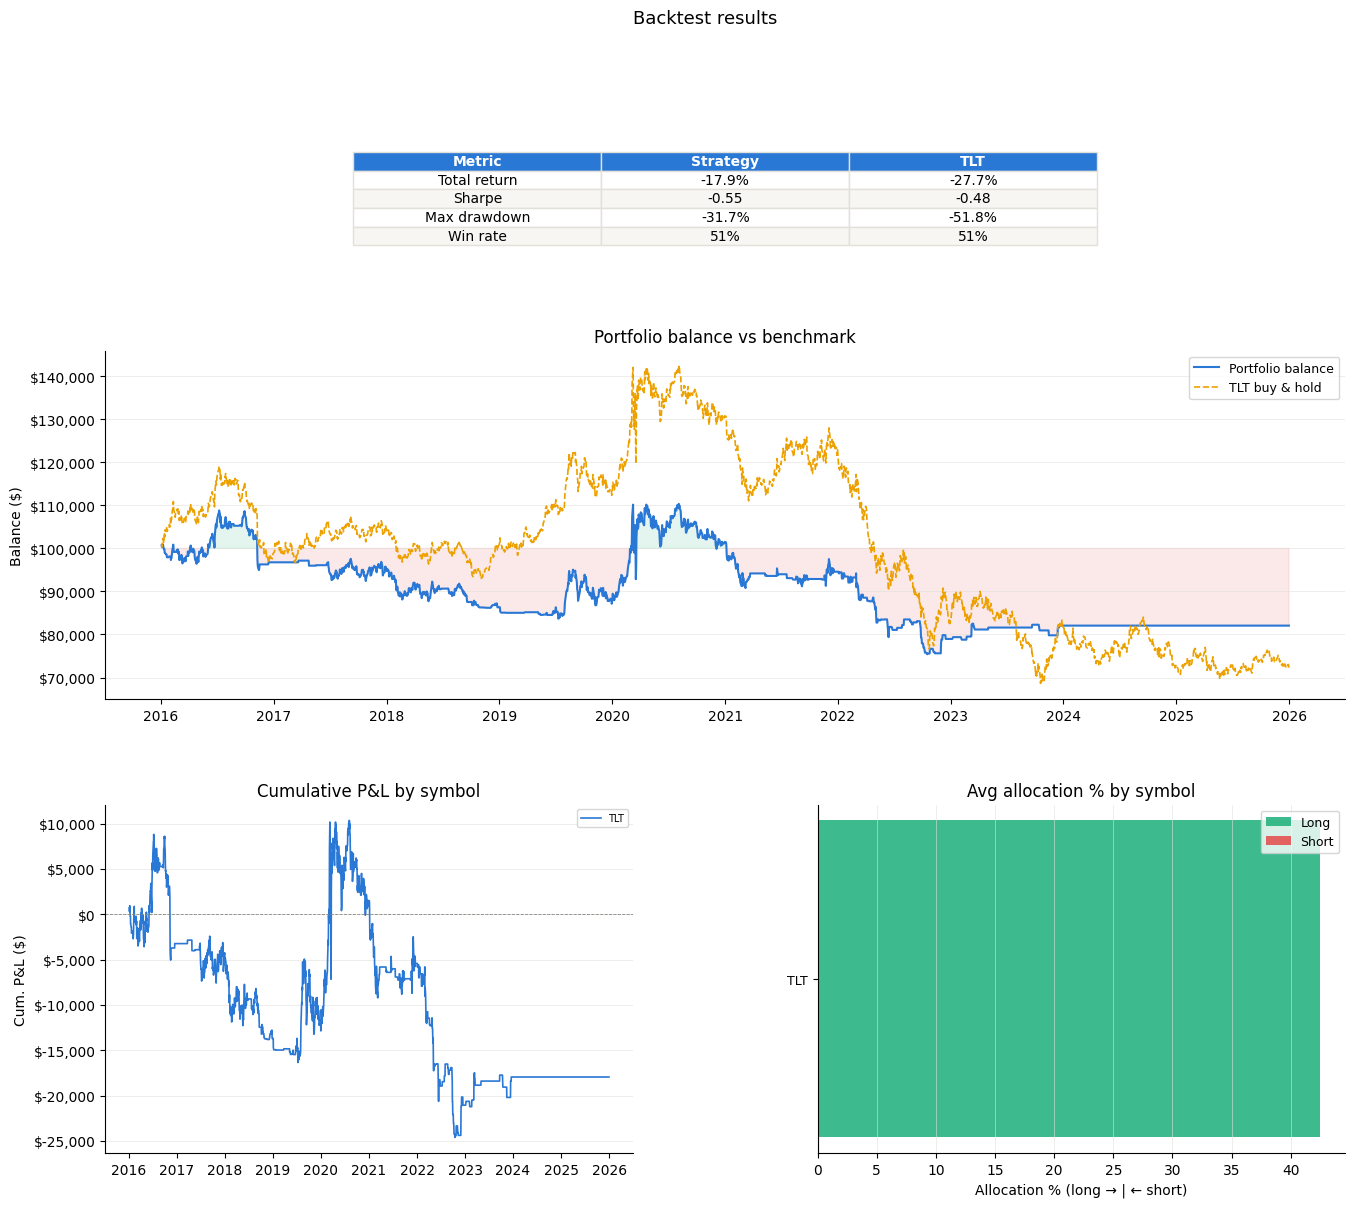

UUP


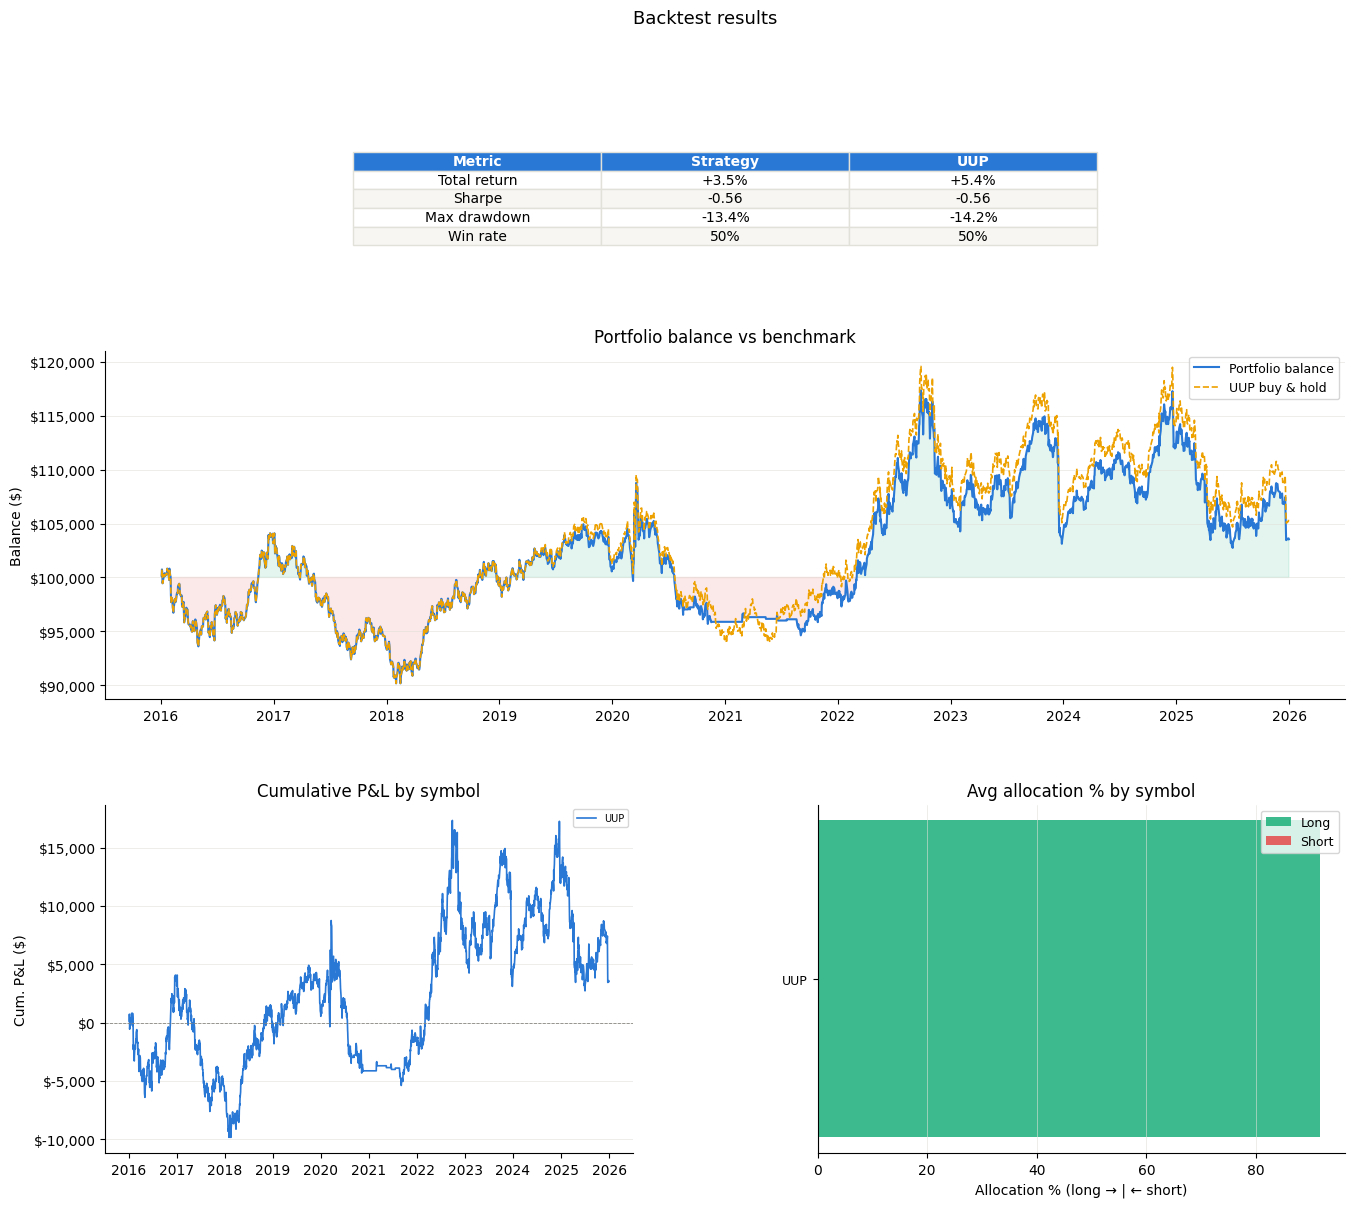

TIP


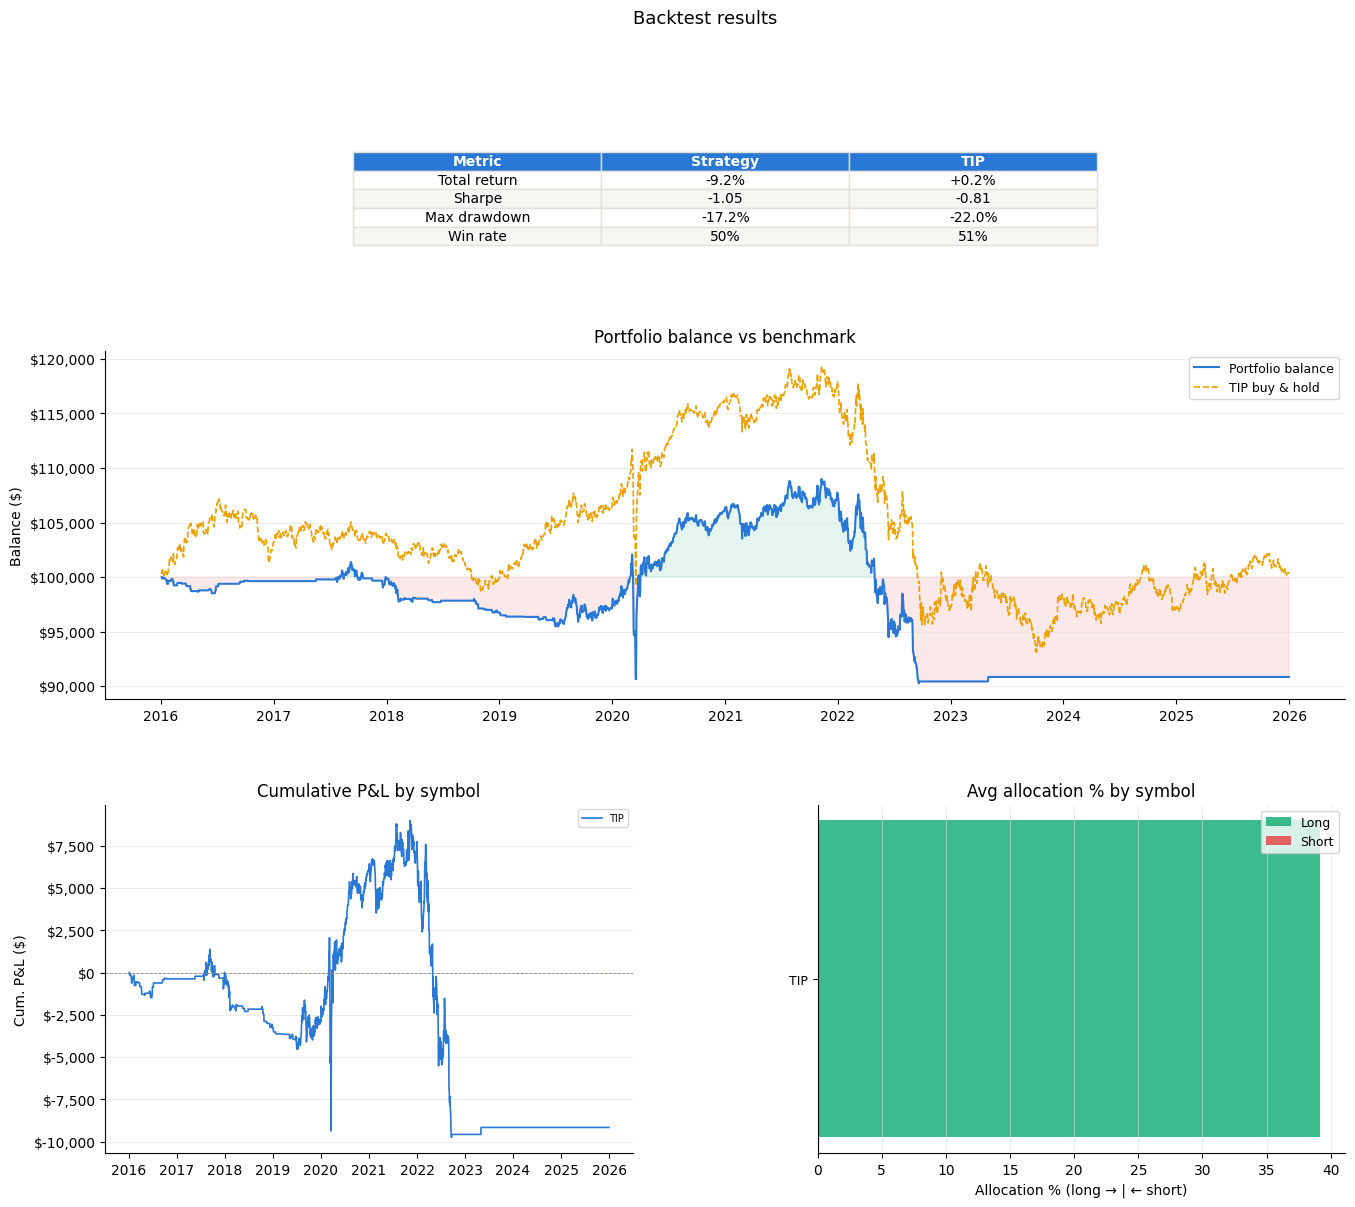

In [ ]:
for i in symbols_selected[:-1]:
  ticker = i.replace("_log_ret", "")
  print(ticker)
  out = run_backtest(selected_result, mode='long_only', start_date='2016-01-01', end_date='2026-01-01', symbols = [ticker])
  plot_backtest(out, selected_result, benchmark_symbol=ticker)